# MIL-CREDA frente a CREDA — el informe (v1)

Este cuaderno no corre nada. Lee lo que dejó `Benchmark_Campaign_v1.ipynb` bajo `MIL-CREDA/Results/Benchmark/` — `summary.json`, `runs.jsonl` y el registro de la búsqueda del techo — y arma las tablas, las figuras y el informe a partir de esos archivos. Corregir una frase del informe cuesta volver a correr esta celda en adelante, segundos, y no la campaña entera.
Diez métodos sobre seis transferencias. Cada peldaño se diferencia del anterior en
**una sola cosa**, así una diferencia se puede atribuir a esa cosa y a ninguna otra.

El nombre dice qué le falta al método: un asterisco marca un componente ausente,
dos marcan dos, y un nombre sin marca es el método completo.

| id | nombre | adaptación | ponderación | término local | instancias que usa |
|---|---|---|---|---|---|
| `A` | `Baseline` | — | — | — | todas |
| `C` | `CREDA*` | CREDA | — | — | todas |
| `D` | `CREDA` | CREDA | sí | — | todas |
| `B` | `MIL-Baseline` | — | — | — | todas |
| `E` | `MIL-CREDA**` | MIL-CREDA | — | — | todas |
| `F` | `MIL-CREDA*` | MIL-CREDA | sí | — | todas |
| `G` | `MIL-CREDA` | MIL-CREDA | sí | sí | todas |
| `SU` | `MIL-CREDA-U` | MIL-CREDA | sí | sí | 10, selección regular |
| `SA` | `MIL-CREDA-A` | MIL-CREDA | sí | sí | 10, selección arbitraria |
| `SK` | `MIL-CREDA-K` | MIL-CREDA | sí | sí | 10, las de mayor atención |

Los últimos tres mantienen fijo el presupuesto de instancias y se diferencian solo
en la regla que lo gasta, así que `MIL-CREDA-U → MIL-CREDA-K` y
`MIL-CREDA-A → MIL-CREDA-K` son atribuibles a la regla. `MIL-CREDA-K → MIL-CREDA`
es la pregunta aparte de cuánto cuesta el presupuesto en sí.

Todo lo de abajo está acotado por `config.py`, y solo dos constantes separan esta
corrida de la completa. **Leer el encabezado de cada tabla antes que sus números**:
por debajo del piso de repeticiones declarado no se otorga ningún veredicto y el
motivo queda estampado.

> **De dónde sale el registro que lee este cuaderno.**
>
> `summary.json` y `runs.jsonl` los escribió `tools/bridge.py` mezclando los diez
> shards que volvieron de los envíos remotos — 30 semillas, 20 épocas, las diez en
> la misma tarjeta. No los escribió `Benchmark_Campaign_v1.ipynb`, que no se
> re-ejecuta y cuyas salidas son de una corrida local anterior. La provenance del
> registro está en `Results/Benchmark/PROVENANCE.txt` y se muestra más abajo.


In [1]:
# Bootstrap: locate the repository wherever this is running, and import from it.
# Local, Colab and Kaggle differ only in where the checkout sits.
import os
import sys
from pathlib import Path


def find_repository() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in (os.environ.get("MIL_CREDA_REPO", ""), "/content", "/kaggle/working"):
        if base and Path(base).is_dir():
            candidates.append(Path(base))
            candidates.extend(sorted(Path(base).glob("*")))
    for candidate in candidates:
        if (candidate / "src" / "MIL_CREDA_Benchmark").is_dir():
            return candidate.resolve()
    raise SystemExit(
        "cannot find the repository. Set MIL_CREDA_REPO to the checkout that "
        "holds src/MIL_CREDA_Benchmark, or run this notebook from inside it."
    )


REPOSITORY = find_repository()
sys.path.insert(0, str(REPOSITORY / "src"))
print("repository:", REPOSITORY)

# Read AND write: this notebook writes into config.RESULTS too (the
# curve PDFs below, report.txt/report.md, the runs it exports), so a
# read-only override would render a scratch merge and then write its
# report into the canonical Results directory -- exactly the copy
# tools/bridge.py's own provenance note forbids. Mirrors MIL_CREDA_REPO
# above: unset means "behave exactly as before".
MIL_CREDA_RESULTS_OVERRIDE = os.environ.get("MIL_CREDA_RESULTS")

repository: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation


In [2]:
import json
from pathlib import Path

from IPython.display import Markdown, display

from MIL_CREDA_Benchmark import config, harness, tables

# The scratch-merge override, resolved once, covering reads AND writes
# below -- see the bootstrap cell for why both directions matter.
RESULTS = Path(MIL_CREDA_RESULTS_OVERRIDE) if MIL_CREDA_RESULTS_OVERRIDE else config.RESULTS
if MIL_CREDA_RESULTS_OVERRIDE:
    print(f"MIL_CREDA_RESULTS override active: {RESULTS}")


def show(text: str) -> None:
    """Una tabla se muestra como tabla, no como texto de ancho fijo.

    Es la misma cadena que va al registro, renderizada. Nada se vuelve a
    calcular acá: si esto y el archivo dijeran cosas distintas, habría dos
    versiones del mismo número y ninguna forma de saber cuál se movió.
    """
    display(Markdown(text))


# Los mismos registros que dejó la corrida, nunca recalculados: si esta
# celda y el archivo dijeran cosas distintas, habría dos versiones del mismo
# número y ninguna forma de saber cuál se movió.
runs = [json.loads(line) for line in
        (RESULTS / "runs.jsonl").read_text().splitlines() if line.strip()]
summary = json.loads((RESULTS / "summary.json").read_text())
reduction = harness.Reduction(**summary["reduction"])
registro_busqueda = harness.search_record()

# Las transferencias salen del registro y no de `config`: la tabla de techos
# describe la corrida que se hizo, no la configuración que hay ahora. Una
# transferencia agregada después dejaría una columna sin datos que igual se
# leería como parte de esta corrida.
TRANSFERENCIAS = list(summary["grid"])

if summary.get("provenance"):
    print(summary["provenance"])
print(f"{len(runs)} corridas · {len(summary['grid'])} transferencias")

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This summary merges 10 shards produced by full campaigns (`harness.campaign()` at `FULL_EPOCHS`), not smoke rehearsals. Arms: A, B, C, D, E, F, G, SA, SK, SU; transfers: M->S, M->U, S->M, S->U, U->M, U->S; epochs per shard: 20; ceiling search: present; seeds: 30. This merge combines real per-machine results but has not been promoted, scale-checked, or certified as a canonical benchmark result; it carries no scientific claim beyond what is stated here on the strength of the merge tool alone. Promotion into `MIL-CREDA/Results/Benchmark/` remains a manual, out-of-scope step.
1800 corridas · 6 transferencias


## 0 · El techo de cada familia

La rejilla entera de la búsqueda, una fila por familia, con el techo elegido
marcado en su propia celda. Va la rejilla y no solo el ganador porque un techo que
gana entre cuatro puntajes idénticos y uno que gana por una diferencia real son el
mismo número y no la misma evidencia, y este escalar gobierna todas las tablas de
abajo.

In [3]:
show(tables.objective("ceilings"))

> **Buscamos que el criterio se incline**, no un número en particular. El neutro es 1: un techo que aterriza ahí confirma la normalización por medición y no por argumento. Lo que invalida la elección es que la búsqueda no distinga —ahí el ganador lo pone la regla y no el criterio—, y la tabla lo dice en la columna que corresponda a su motor: una rejilla plana con semillas que no coinciden, o una meseta ancha. **Meseta uno significa que el criterio decidió.** Sobre el rango continuo la meseta la define la resolución del instrumento, 0.05, que es una bolsa de las 20 del rol de búsqueda: dos techos que difieren en menos que eso no son distinguibles por la medición.

In [4]:
show(tables.render_ceilings(registro_busqueda, markdown=True))

| Familia | Brazo | 0.0001 | 0.001 | 0.01 | 0.1 | 1 |
|---|---|---|---|---|---|---|
| `creda` | `D` | **85.8** | 85.8 | 85.8 | 59.2 | 50.0 |
| `milcreda` | `G` | 45.8 | 47.5 | **60.0** | 55.0 | 43.3 |

In [5]:
show(tables.conclusion_ceilings(registro_busqueda))

**creda** se queda en 0.0001, elegido por desempate entre 3 techos empatados sobre el rol `valid` con 3 repetición(es) de 20 épocas y las semillas **no** coinciden entre sí. **milcreda** se queda en 0.01, elegido por una diferencia en el criterio sobre el rol `valid` con 3 repetición(es) de 20 épocas y las semillas coinciden. Para creda la rejilla no se inclinó: el techo lo puso la regla y no el criterio, así que sostiene menos de lo que un número elegido parece sostener.

### 0b · Qué techo rige en cada transferencia

La búsqueda midió dos de las seis transferencias. En esas dos rige el techo que
ganó ahí; en las otras cuatro rige el ganador de las dos tomadas juntas, aplicado
fuera de muestra. Las celdas marcadas son las medidas, y la distinción importa:
un número elegido mirando esa transferencia y uno heredado de otras dos son el
mismo número y no la misma evidencia.


In [6]:
show(tables.objective("ceilings.byTransfer"))

> **Buscamos saber cuántas de las 6 transferencias corren a un techo elegido mirándolas.** La búsqueda mide 6; las otras 0 heredan, y esa herencia es una aplicación fuera de muestra. Lo que hay que ver es si alguna de las medidas se aparta del ganador agrupado: si ninguna lo hace, separar las dos lecturas no cambió nada y la familia sigue corriendo a un coeficiente único; si alguna se aparta, deja de hacerlo y su promedio entre transferencias mezcla dos escalares.

In [7]:
show(tables.render_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS, markdown=True))

| Familia | M->U | U->M | M->S | S->M | U->S | S->U |
|---|---|---|---|---|---|---|
| `creda` | **0.0001** | 0.0001 | 0.0001 | **0.0001** | 0.0001 | 0.0001 |
| `milcreda` | **0.01** | 0.01 | 0.01 | **0.0001** | 0.01 | 0.01 |

In [8]:
show(tables.conclusion_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS))

En las transferencias que la búsqueda midió rige el ganador de esa transferencia, por la misma lectura apareada y el mismo desempate. En las restantes rige el ganador de las medidas tomadas juntas: es una aplicación fuera de muestra y se declara como tal, porque ese escalar no se eligió mirándolas. **creda**: 2 medida(s) y 4 heredada(s), todas en 0.0001. Ninguna transferencia medida se aparta del ganador agrupado, así que separar las dos lecturas no cambió ningún techo de esta familia. **milcreda**: 2 medida(s), 4 heredada(s) a 0.01, y 1 de las medidas elige otro techo — `S->M` a 0.0001. Ahí la familia deja de correr a un coeficiente único, así que su promedio entre transferencias mezcla dos escalares; dentro de cada transferencia todos los brazos siguen compartiendo el techo, que es lo que mantiene atribuible cada peldaño.

## Bajo qué corrió todo esto

Los límites de la corrida se dicen una vez, acá, y atan todo lo que sigue. No se
repiten en el encabezado de cada tabla: un aviso que aparece ocho veces enseña a
saltearlo, que es lo contrario de para lo que está.

In [9]:
show(tables.stamp(summary["reduction"], markdown=True))

> resnet18  ·  20 épocas  ·  30 repetición(es)  ·  research-concept-r17.md  
> la exactitud se mueve de a 2.78 puntos sobre 36 bolsas de evaluación: nada por debajo de eso lo resuelve una transferencia sola  

## 1 · Tiempo de entrenamiento

Los segundos que tarda una corrida completa de cada método en cada transferencia,
con el mismo backbone y la misma cantidad de pasos. Va primero porque un método que
gana pagando diez veces el cómputo no gana lo mismo que uno que gana gratis, y porque
el costo es lo único que se compara limpio aunque las dos familias predigan sobre
unidades distintas. Buscamos el número más bajo, y sobre todo que la diferencia entre
métodos sea chica: un método más lento sigue siendo utilizable, uno diez veces más
lento deja de serlo.

Cuando la corrida vino de más de una máquina, esta sección no promedia: `seconds` no
demostró ser una propiedad del método ni de una máquina fija — ni siquiera entre dos
corridas de la misma máquina — así que cada fila de abajo es una corrida sola, con su
propio entorno a la vista.

In [10]:
show(tables.objective("seconds"))

> **Buscamos el número más bajo**, y sobre todo que la diferencia entre métodos sea chica: uno más lento sigue siendo utilizable, uno diez veces más lento deja de serlo.

In [11]:
# `seconds` is `perRun`: a distributed campaign's summary carries
# `gridPerRun` and this renders one row per run, tagged with its own
# environment, never pooled into a mean. A single-machine `campaign()`
# summary has no `gridPerRun` key at all, so this falls back to the pooled
# table exactly as before.
if summary.get("gridPerRun"):
    show(tables.render_per_run(summary["gridPerRun"], "seconds", markdown=True))
else:
    show(tables.render(runs, "seconds", summary["reduction"], markdown=True))

> cada fila es una corrida en su propia máquina, nunca promediada con otra: no hay una columna de método que hable por todas.  

| Método | Transferencia | Entorno | Semilla | tiempo de entrenamiento (s) |
|---|---|---|---|---|
| `Baseline` | M->U | `56e99cacbd39` | 0 | 21.91 |
| `Baseline` | M->U | `56e99cacbd39` | 1 | 22.73 |
| `Baseline` | M->U | `56e99cacbd39` | 2 | 22.66 |
| `Baseline` | M->U | `56e99cacbd39` | 3 | 21.13 |
| `Baseline` | M->U | `56e99cacbd39` | 4 | 24.45 |
| `Baseline` | M->U | `56e99cacbd39` | 5 | 24.56 |
| `Baseline` | M->U | `56e99cacbd39` | 6 | 22.07 |
| `Baseline` | M->U | `56e99cacbd39` | 7 | 23.48 |
| `Baseline` | M->U | `56e99cacbd39` | 8 | 23.64 |
| `Baseline` | M->U | `56e99cacbd39` | 9 | 20.61 |
| `Baseline` | M->U | `56e99cacbd39` | 10 | 22.25 |
| `Baseline` | M->U | `56e99cacbd39` | 11 | 22.27 |
| `Baseline` | M->U | `56e99cacbd39` | 12 | 21.70 |
| `Baseline` | M->U | `56e99cacbd39` | 13 | 23.41 |
| `Baseline` | M->U | `56e99cacbd39` | 14 | 23.43 |
| `Baseline` | M->U | `56e99cacbd39` | 15 | 21.31 |
| `Baseline` | M->U | `56e99cacbd39` | 16 | 23.82 |
| `Baseline` | M->U | `56e99cacbd39` | 17 | 21.64 |
| `Baseline` | M->U | `56e99cacbd39` | 18 | 22.68 |
| `Baseline` | M->U | `56e99cacbd39` | 19 | 24.47 |
| `Baseline` | M->U | `56e99cacbd39` | 20 | 24.35 |
| `Baseline` | M->U | `56e99cacbd39` | 21 | 21.46 |
| `Baseline` | M->U | `56e99cacbd39` | 22 | 22.83 |
| `Baseline` | M->U | `56e99cacbd39` | 23 | 22.86 |
| `Baseline` | M->U | `56e99cacbd39` | 24 | 21.14 |
| `Baseline` | M->U | `56e99cacbd39` | 25 | 23.28 |
| `Baseline` | M->U | `56e99cacbd39` | 26 | 23.24 |
| `Baseline` | M->U | `56e99cacbd39` | 27 | 21.29 |
| `Baseline` | M->U | `56e99cacbd39` | 28 | 24.57 |
| `Baseline` | M->U | `56e99cacbd39` | 29 | 24.70 |
| `CREDA*` | M->U | `56e99cacbd39` | 0 | 44.29 |
| `CREDA*` | M->U | `56e99cacbd39` | 1 | 45.32 |
| `CREDA*` | M->U | `56e99cacbd39` | 2 | 46.03 |
| `CREDA*` | M->U | `56e99cacbd39` | 3 | 42.89 |
| `CREDA*` | M->U | `56e99cacbd39` | 4 | 46.91 |
| `CREDA*` | M->U | `56e99cacbd39` | 5 | 46.73 |
| `CREDA*` | M->U | `56e99cacbd39` | 6 | 44.61 |
| `CREDA*` | M->U | `56e99cacbd39` | 7 | 46.36 |
| `CREDA*` | M->U | `56e99cacbd39` | 8 | 46.65 |
| `CREDA*` | M->U | `56e99cacbd39` | 9 | 41.45 |
| `CREDA*` | M->U | `56e99cacbd39` | 10 | 44.74 |
| `CREDA*` | M->U | `56e99cacbd39` | 11 | 44.68 |
| `CREDA*` | M->U | `56e99cacbd39` | 12 | 44.49 |
| `CREDA*` | M->U | `56e99cacbd39` | 13 | 45.95 |
| `CREDA*` | M->U | `56e99cacbd39` | 14 | 45.86 |
| `CREDA*` | M->U | `56e99cacbd39` | 15 | 44.09 |
| `CREDA*` | M->U | `56e99cacbd39` | 16 | 46.80 |
| `CREDA*` | M->U | `56e99cacbd39` | 17 | 44.57 |
| `CREDA*` | M->U | `56e99cacbd39` | 18 | 45.00 |
| `CREDA*` | M->U | `56e99cacbd39` | 19 | 49.43 |
| `CREDA*` | M->U | `56e99cacbd39` | 20 | 49.91 |
| `CREDA*` | M->U | `56e99cacbd39` | 21 | 43.90 |
| `CREDA*` | M->U | `56e99cacbd39` | 22 | 44.95 |
| `CREDA*` | M->U | `56e99cacbd39` | 23 | 44.79 |
| `CREDA*` | M->U | `56e99cacbd39` | 24 | 43.05 |
| `CREDA*` | M->U | `56e99cacbd39` | 25 | 45.55 |
| `CREDA*` | M->U | `56e99cacbd39` | 26 | 45.60 |
| `CREDA*` | M->U | `56e99cacbd39` | 27 | 43.04 |
| `CREDA*` | M->U | `56e99cacbd39` | 28 | 47.78 |
| `CREDA*` | M->U | `56e99cacbd39` | 29 | 48.33 |
| `CREDA` | M->U | `56e99cacbd39` | 0 | 45.93 |
| `CREDA` | M->U | `56e99cacbd39` | 1 | 45.82 |
| `CREDA` | M->U | `56e99cacbd39` | 2 | 46.16 |
| `CREDA` | M->U | `56e99cacbd39` | 3 | 45.80 |
| `CREDA` | M->U | `56e99cacbd39` | 4 | 47.93 |
| `CREDA` | M->U | `56e99cacbd39` | 5 | 48.09 |
| `CREDA` | M->U | `56e99cacbd39` | 6 | 47.13 |
| `CREDA` | M->U | `56e99cacbd39` | 7 | 46.98 |
| `CREDA` | M->U | `56e99cacbd39` | 8 | 46.95 |
| `CREDA` | M->U | `56e99cacbd39` | 9 | 42.87 |
| `CREDA` | M->U | `56e99cacbd39` | 10 | 45.42 |
| `CREDA` | M->U | `56e99cacbd39` | 11 | 45.15 |
| `CREDA` | M->U | `56e99cacbd39` | 12 | 47.10 |
| `CREDA` | M->U | `56e99cacbd39` | 13 | 46.65 |
| `CREDA` | M->U | `56e99cacbd39` | 14 | 46.73 |
| `CREDA` | M->U | `56e99cacbd39` | 15 | 45.17 |
| `CREDA` | M->U | `56e99cacbd39` | 16 | 47.32 |
| `CREDA` | M->U | `56e99cacbd39` | 17 | 45.51 |
| `CREDA` | M->U | `56e99cacbd39` | 18 | 47.26 |
| `CREDA` | M->U | `56e99cacbd39` | 19 | 50.46 |
| `CREDA` | M->U | `56e99cacbd39` | 20 | 50.28 |
| `CREDA` | M->U | `56e99cacbd39` | 21 | 46.19 |
| `CREDA` | M->U | `56e99cacbd39` | 22 | 45.83 |
| `CREDA` | M->U | `56e99cacbd39` | 23 | 45.71 |
| `CREDA` | M->U | `56e99cacbd39` | 24 | 45.43 |
| `CREDA` | M->U | `56e99cacbd39` | 25 | 46.26 |
| `CREDA` | M->U | `56e99cacbd39` | 26 | 46.35 |
| `CREDA` | M->U | `56e99cacbd39` | 27 | 44.77 |
| `CREDA` | M->U | `56e99cacbd39` | 28 | 49.16 |
| `CREDA` | M->U | `56e99cacbd39` | 29 | 49.94 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 0 | 22.93 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 1 | 22.69 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 2 | 22.69 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 3 | 25.10 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 4 | 23.98 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 5 | 23.84 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 6 | 24.11 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 7 | 23.53 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 8 | 23.52 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 9 | 22.06 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 10 | 22.32 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 11 | 22.27 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 12 | 23.70 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 13 | 23.34 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 14 | 23.32 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 15 | 21.81 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 16 | 23.88 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 17 | 22.71 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 18 | 24.30 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 19 | 24.54 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 20 | 24.63 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 21 | 22.46 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 22 | 22.58 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 23 | 22.61 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 24 | 23.75 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 25 | 23.12 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 26 | 23.05 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 27 | 22.12 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 28 | 23.78 |
| `MIL-Baseline` | M->U | `56e99cacbd39` | 29 | 23.85 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 0 | 99.16 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 1 | 90.11 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 2 | 91.17 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 3 | 90.44 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 4 | 90.04 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 5 | 90.01 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 6 | 92.79 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 7 | 91.24 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 8 | 89.63 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 9 | 87.02 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 10 | 89.19 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 11 | 89.03 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 12 | 98.89 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 13 | 89.55 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 14 | 88.77 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 15 | 95.91 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 16 | 91.69 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 17 | 88.70 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 18 | 99.97 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 19 | 100.01 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 20 | 100.01 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 21 | 89.54 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 22 | 89.67 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 23 | 89.04 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 24 | 89.50 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 25 | 89.58 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 26 | 89.57 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 27 | 91.80 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 28 | 97.88 |
| `MIL-CREDA**` | M->U | `56e99cacbd39` | 29 | 100.48 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 0 | 98.17 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 1 | 90.57 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 2 | 91.00 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 3 | 90.50 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 4 | 90.74 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 5 | 91.51 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 6 | 93.45 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 7 | 91.12 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 8 | 89.51 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 9 | 89.05 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 10 | 89.20 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 11 | 90.00 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 12 | 91.30 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 13 | 89.76 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 14 | 89.62 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 15 | 96.07 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 16 | 90.87 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 17 | 88.59 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 18 | 100.39 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 19 | 101.73 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 20 | 100.59 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 21 | 89.97 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 22 | 89.45 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 23 | 89.58 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 24 | 90.04 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 25 | 90.06 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 26 | 90.03 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 27 | 92.00 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 28 | 98.69 |
| `MIL-CREDA*` | M->U | `56e99cacbd39` | 29 | 100.16 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 0 | 104.89 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 1 | 101.16 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 2 | 104.37 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 3 | 100.81 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 4 | 100.24 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 5 | 100.58 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 6 | 103.34 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 7 | 100.70 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 8 | 99.44 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 9 | 100.77 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 10 | 98.58 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 11 | 102.35 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 12 | 99.68 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 13 | 99.93 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 14 | 99.32 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 15 | 108.65 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 16 | 99.57 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 17 | 98.97 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 18 | 110.96 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 19 | 112.59 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 20 | 112.43 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 21 | 99.87 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 22 | 99.20 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 23 | 100.51 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 24 | 99.88 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 25 | 100.05 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 26 | 100.93 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 27 | 103.11 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 28 | 108.85 |
| `MIL-CREDA` | M->U | `56e99cacbd39` | 29 | 112.66 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 0 | 103.83 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 1 | 100.22 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 2 | 104.81 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 3 | 99.85 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 4 | 99.69 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 5 | 100.99 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 6 | 103.07 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 7 | 101.00 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 8 | 98.78 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 9 | 101.70 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 10 | 97.07 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 11 | 98.36 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 12 | 99.81 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 13 | 99.12 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 14 | 99.18 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 15 | 108.83 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 16 | 99.18 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 17 | 97.43 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 18 | 111.19 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 19 | 111.06 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 20 | 111.38 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 21 | 99.68 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 22 | 99.52 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 23 | 99.41 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 24 | 100.30 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 25 | 99.90 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 26 | 99.88 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 27 | 103.45 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 28 | 108.72 |
| `MIL-CREDA-U` | M->U | `56e99cacbd39` | 29 | 108.72 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 0 | 102.10 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 1 | 99.77 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 2 | 101.34 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 3 | 100.48 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 4 | 100.75 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 5 | 100.48 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 6 | 102.21 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 7 | 100.18 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 8 | 99.87 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 9 | 99.44 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 10 | 98.15 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 11 | 98.31 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 12 | 99.33 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 13 | 98.47 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 14 | 98.65 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 15 | 108.59 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 16 | 98.40 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 17 | 98.50 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 18 | 110.04 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 19 | 110.55 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 20 | 110.92 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 21 | 99.54 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 22 | 99.66 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 23 | 98.96 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 24 | 99.49 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 25 | 99.36 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 26 | 99.34 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 27 | 102.50 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 28 | 106.99 |
| `MIL-CREDA-A` | M->U | `56e99cacbd39` | 29 | 104.96 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 0 | 103.27 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 1 | 100.09 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 2 | 101.90 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 3 | 100.02 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 4 | 100.21 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 5 | 100.99 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 6 | 103.45 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 7 | 101.34 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 8 | 99.14 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 9 | 99.03 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 10 | 99.19 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 11 | 98.91 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 12 | 100.56 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 13 | 100.17 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 14 | 99.30 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 15 | 109.87 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 16 | 99.21 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 17 | 98.30 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 18 | 110.20 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 19 | 110.01 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 20 | 110.52 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 21 | 100.38 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 22 | 100.15 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 23 | 99.70 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 24 | 100.21 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 25 | 100.05 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 26 | 100.20 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 27 | 103.48 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 28 | 107.54 |
| `MIL-CREDA-K` | M->U | `56e99cacbd39` | 29 | 107.10 |
| `Baseline` | U->M | `56e99cacbd39` | 0 | 22.67 |
| `Baseline` | U->M | `56e99cacbd39` | 1 | 22.66 |
| `Baseline` | U->M | `56e99cacbd39` | 2 | 22.67 |
| `Baseline` | U->M | `56e99cacbd39` | 3 | 24.00 |
| `Baseline` | U->M | `56e99cacbd39` | 4 | 24.13 |
| `Baseline` | U->M | `56e99cacbd39` | 5 | 24.04 |
| `Baseline` | U->M | `56e99cacbd39` | 6 | 23.47 |
| `Baseline` | U->M | `56e99cacbd39` | 7 | 23.34 |
| `Baseline` | U->M | `56e99cacbd39` | 8 | 23.34 |
| `Baseline` | U->M | `56e99cacbd39` | 9 | 22.19 |
| `Baseline` | U->M | `56e99cacbd39` | 10 | 22.13 |
| `Baseline` | U->M | `56e99cacbd39` | 11 | 22.17 |
| `Baseline` | U->M | `56e99cacbd39` | 12 | 23.28 |
| `Baseline` | U->M | `56e99cacbd39` | 13 | 23.25 |
| `Baseline` | U->M | `56e99cacbd39` | 14 | 23.22 |
| `Baseline` | U->M | `56e99cacbd39` | 15 | 23.89 |
| `Baseline` | U->M | `56e99cacbd39` | 16 | 21.74 |
| `Baseline` | U->M | `56e99cacbd39` | 17 | 21.71 |
| `Baseline` | U->M | `56e99cacbd39` | 18 | 24.58 |
| `Baseline` | U->M | `56e99cacbd39` | 19 | 24.50 |
| `Baseline` | U->M | `56e99cacbd39` | 20 | 24.49 |
| `Baseline` | U->M | `56e99cacbd39` | 21 | 22.54 |
| `Baseline` | U->M | `56e99cacbd39` | 22 | 22.59 |
| `Baseline` | U->M | `56e99cacbd39` | 23 | 22.58 |
| `Baseline` | U->M | `56e99cacbd39` | 24 | 23.07 |
| `Baseline` | U->M | `56e99cacbd39` | 25 | 23.07 |
| `Baseline` | U->M | `56e99cacbd39` | 26 | 23.02 |
| `Baseline` | U->M | `56e99cacbd39` | 27 | 22.72 |
| `Baseline` | U->M | `56e99cacbd39` | 28 | 24.02 |
| `Baseline` | U->M | `56e99cacbd39` | 29 | 24.02 |
| `CREDA*` | U->M | `56e99cacbd39` | 0 | 45.38 |
| `CREDA*` | U->M | `56e99cacbd39` | 1 | 45.12 |
| `CREDA*` | U->M | `56e99cacbd39` | 2 | 45.36 |
| `CREDA*` | U->M | `56e99cacbd39` | 3 | 46.77 |
| `CREDA*` | U->M | `56e99cacbd39` | 4 | 46.75 |
| `CREDA*` | U->M | `56e99cacbd39` | 5 | 46.84 |
| `CREDA*` | U->M | `56e99cacbd39` | 6 | 46.51 |
| `CREDA*` | U->M | `56e99cacbd39` | 7 | 46.30 |
| `CREDA*` | U->M | `56e99cacbd39` | 8 | 45.75 |
| `CREDA*` | U->M | `56e99cacbd39` | 9 | 44.28 |
| `CREDA*` | U->M | `56e99cacbd39` | 10 | 44.40 |
| `CREDA*` | U->M | `56e99cacbd39` | 11 | 44.18 |
| `CREDA*` | U->M | `56e99cacbd39` | 12 | 45.96 |
| `CREDA*` | U->M | `56e99cacbd39` | 13 | 46.03 |
| `CREDA*` | U->M | `56e99cacbd39` | 14 | 46.19 |
| `CREDA*` | U->M | `56e99cacbd39` | 15 | 47.01 |
| `CREDA*` | U->M | `56e99cacbd39` | 16 | 44.84 |
| `CREDA*` | U->M | `56e99cacbd39` | 17 | 44.73 |
| `CREDA*` | U->M | `56e99cacbd39` | 18 | 48.87 |
| `CREDA*` | U->M | `56e99cacbd39` | 19 | 49.01 |
| `CREDA*` | U->M | `56e99cacbd39` | 20 | 48.75 |
| `CREDA*` | U->M | `56e99cacbd39` | 21 | 45.08 |
| `CREDA*` | U->M | `56e99cacbd39` | 22 | 44.86 |
| `CREDA*` | U->M | `56e99cacbd39` | 23 | 44.82 |
| `CREDA*` | U->M | `56e99cacbd39` | 24 | 45.44 |
| `CREDA*` | U->M | `56e99cacbd39` | 25 | 45.54 |
| `CREDA*` | U->M | `56e99cacbd39` | 26 | 45.38 |
| `CREDA*` | U->M | `56e99cacbd39` | 27 | 46.67 |
| `CREDA*` | U->M | `56e99cacbd39` | 28 | 47.03 |
| `CREDA*` | U->M | `56e99cacbd39` | 29 | 47.64 |
| `CREDA` | U->M | `56e99cacbd39` | 0 | 46.30 |
| `CREDA` | U->M | `56e99cacbd39` | 1 | 45.91 |
| `CREDA` | U->M | `56e99cacbd39` | 2 | 46.06 |
| `CREDA` | U->M | `56e99cacbd39` | 3 | 47.71 |
| `CREDA` | U->M | `56e99cacbd39` | 4 | 47.98 |
| `CREDA` | U->M | `56e99cacbd39` | 5 | 48.04 |
| `CREDA` | U->M | `56e99cacbd39` | 6 | 47.33 |
| `CREDA` | U->M | `56e99cacbd39` | 7 | 46.94 |
| `CREDA` | U->M | `56e99cacbd39` | 8 | 46.73 |
| `CREDA` | U->M | `56e99cacbd39` | 9 | 45.17 |
| `CREDA` | U->M | `56e99cacbd39` | 10 | 45.23 |
| `CREDA` | U->M | `56e99cacbd39` | 11 | 45.15 |
| `CREDA` | U->M | `56e99cacbd39` | 12 | 46.85 |
| `CREDA` | U->M | `56e99cacbd39` | 13 | 46.83 |
| `CREDA` | U->M | `56e99cacbd39` | 14 | 46.77 |
| `CREDA` | U->M | `56e99cacbd39` | 15 | 48.12 |
| `CREDA` | U->M | `56e99cacbd39` | 16 | 45.69 |
| `CREDA` | U->M | `56e99cacbd39` | 17 | 45.54 |
| `CREDA` | U->M | `56e99cacbd39` | 18 | 50.09 |
| `CREDA` | U->M | `56e99cacbd39` | 19 | 49.89 |
| `CREDA` | U->M | `56e99cacbd39` | 20 | 49.83 |
| `CREDA` | U->M | `56e99cacbd39` | 21 | 45.82 |
| `CREDA` | U->M | `56e99cacbd39` | 22 | 45.66 |
| `CREDA` | U->M | `56e99cacbd39` | 23 | 45.47 |
| `CREDA` | U->M | `56e99cacbd39` | 24 | 46.36 |
| `CREDA` | U->M | `56e99cacbd39` | 25 | 46.09 |
| `CREDA` | U->M | `56e99cacbd39` | 26 | 46.38 |
| `CREDA` | U->M | `56e99cacbd39` | 27 | 48.64 |
| `CREDA` | U->M | `56e99cacbd39` | 28 | 48.17 |
| `CREDA` | U->M | `56e99cacbd39` | 29 | 48.73 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 0 | 22.68 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 1 | 22.70 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 2 | 22.70 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 3 | 23.97 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 4 | 23.87 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 5 | 23.99 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 6 | 23.57 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 7 | 23.41 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 8 | 23.48 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 9 | 22.26 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 10 | 22.28 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 11 | 22.25 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 12 | 23.35 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 13 | 23.37 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 14 | 23.39 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 15 | 24.01 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 16 | 22.69 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 17 | 22.67 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 18 | 24.59 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 19 | 24.49 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 20 | 24.29 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 21 | 22.57 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 22 | 22.52 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 23 | 22.55 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 24 | 23.06 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 25 | 22.95 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 26 | 22.90 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 27 | 23.94 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 28 | 23.89 |
| `MIL-Baseline` | U->M | `56e99cacbd39` | 29 | 24.24 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 0 | 90.47 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 1 | 89.68 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 2 | 90.10 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 3 | 89.97 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 4 | 90.63 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 5 | 90.45 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 6 | 91.90 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 7 | 90.27 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 8 | 92.03 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 9 | 87.98 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 10 | 88.58 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 11 | 87.79 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 12 | 89.36 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 13 | 88.86 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 14 | 88.75 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 15 | 95.53 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 16 | 89.19 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 17 | 89.29 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 18 | 98.76 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 19 | 97.74 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 20 | 99.31 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 21 | 89.16 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 22 | 89.30 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 23 | 88.93 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 24 | 89.30 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 25 | 89.12 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 26 | 89.32 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 27 | 94.08 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 28 | 92.03 |
| `MIL-CREDA**` | U->M | `56e99cacbd39` | 29 | 97.53 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 0 | 91.19 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 1 | 90.39 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 2 | 90.95 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 3 | 89.84 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 4 | 90.77 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 5 | 91.89 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 6 | 92.24 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 7 | 91.22 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 8 | 90.78 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 9 | 88.52 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 10 | 90.16 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 11 | 88.35 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 12 | 89.97 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 13 | 90.01 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 14 | 89.28 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 15 | 94.96 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 16 | 89.01 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 17 | 88.90 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 18 | 99.83 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 19 | 98.95 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 20 | 98.14 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 21 | 89.75 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 22 | 90.72 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 23 | 89.36 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 24 | 90.17 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 25 | 89.96 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 26 | 89.60 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 27 | 94.17 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 28 | 93.67 |
| `MIL-CREDA*` | U->M | `56e99cacbd39` | 29 | 99.51 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 0 | 104.13 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 1 | 99.91 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 2 | 101.36 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 3 | 99.90 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 4 | 100.75 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 5 | 101.73 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 6 | 102.49 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 7 | 100.45 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 8 | 100.43 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 9 | 98.71 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 10 | 97.81 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 11 | 98.24 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 12 | 100.33 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 13 | 99.24 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 14 | 99.24 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 15 | 109.10 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 16 | 99.44 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 17 | 99.04 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 18 | 111.57 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 19 | 108.65 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 20 | 109.61 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 21 | 100.16 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 22 | 99.86 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 23 | 100.08 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 24 | 100.08 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 25 | 99.77 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 26 | 100.58 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 27 | 103.83 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 28 | 104.68 |
| `MIL-CREDA` | U->M | `56e99cacbd39` | 29 | 105.96 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 0 | 102.42 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 1 | 99.94 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 2 | 100.26 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 3 | 99.52 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 4 | 100.26 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 5 | 99.58 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 6 | 101.43 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 7 | 99.85 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 8 | 99.21 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 9 | 97.88 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 10 | 96.73 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 11 | 99.81 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 12 | 99.39 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 13 | 98.71 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 14 | 99.18 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 15 | 107.88 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 16 | 98.33 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 17 | 97.46 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 18 | 110.37 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 19 | 107.71 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 20 | 110.40 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 21 | 99.61 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 22 | 100.29 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 23 | 98.90 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 24 | 99.16 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 25 | 99.37 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 26 | 99.57 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 27 | 102.64 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 28 | 103.52 |
| `MIL-CREDA-U` | U->M | `56e99cacbd39` | 29 | 105.90 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 0 | 101.94 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 1 | 99.46 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 2 | 99.87 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 3 | 99.76 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 4 | 100.13 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 5 | 99.75 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 6 | 102.08 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 7 | 99.59 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 8 | 99.65 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 9 | 97.60 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 10 | 97.64 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 11 | 98.02 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 12 | 99.99 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 13 | 98.48 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 14 | 98.99 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 15 | 108.36 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 16 | 98.71 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 17 | 98.12 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 18 | 111.18 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 19 | 108.24 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 20 | 109.49 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 21 | 99.77 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 22 | 99.94 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 23 | 98.83 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 24 | 100.03 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 25 | 99.07 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 26 | 99.40 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 27 | 103.55 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 28 | 102.62 |
| `MIL-CREDA-A` | U->M | `56e99cacbd39` | 29 | 104.07 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 0 | 104.03 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 1 | 99.72 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 2 | 100.34 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 3 | 99.56 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 4 | 100.30 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 5 | 99.67 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 6 | 101.68 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 7 | 100.32 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 8 | 99.34 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 9 | 98.55 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 10 | 96.32 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 11 | 98.05 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 12 | 99.50 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 13 | 99.28 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 14 | 99.01 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 15 | 108.59 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 16 | 98.38 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 17 | 97.99 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 18 | 110.40 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 19 | 108.38 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 20 | 109.74 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 21 | 98.96 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 22 | 100.31 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 23 | 100.01 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 24 | 99.58 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 25 | 99.35 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 26 | 99.53 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 27 | 103.83 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 28 | 102.70 |
| `MIL-CREDA-K` | U->M | `56e99cacbd39` | 29 | 103.42 |
| `Baseline` | M->S | `56e99cacbd39` | 0 | 22.70 |
| `Baseline` | M->S | `56e99cacbd39` | 1 | 22.67 |
| `Baseline` | M->S | `56e99cacbd39` | 2 | 22.68 |
| `Baseline` | M->S | `56e99cacbd39` | 3 | 23.99 |
| `Baseline` | M->S | `56e99cacbd39` | 4 | 23.98 |
| `Baseline` | M->S | `56e99cacbd39` | 5 | 24.20 |
| `Baseline` | M->S | `56e99cacbd39` | 6 | 23.46 |
| `Baseline` | M->S | `56e99cacbd39` | 7 | 23.41 |
| `Baseline` | M->S | `56e99cacbd39` | 8 | 23.43 |
| `Baseline` | M->S | `56e99cacbd39` | 9 | 22.10 |
| `Baseline` | M->S | `56e99cacbd39` | 10 | 22.12 |
| `Baseline` | M->S | `56e99cacbd39` | 11 | 22.06 |
| `Baseline` | M->S | `56e99cacbd39` | 12 | 23.27 |
| `Baseline` | M->S | `56e99cacbd39` | 13 | 23.27 |
| `Baseline` | M->S | `56e99cacbd39` | 14 | 23.28 |
| `Baseline` | M->S | `56e99cacbd39` | 15 | 21.68 |
| `Baseline` | M->S | `56e99cacbd39` | 16 | 21.67 |
| `Baseline` | M->S | `56e99cacbd39` | 17 | 21.76 |
| `Baseline` | M->S | `56e99cacbd39` | 18 | 24.43 |
| `Baseline` | M->S | `56e99cacbd39` | 19 | 24.45 |
| `Baseline` | M->S | `56e99cacbd39` | 20 | 24.49 |
| `Baseline` | M->S | `56e99cacbd39` | 21 | 22.59 |
| `Baseline` | M->S | `56e99cacbd39` | 22 | 22.56 |
| `Baseline` | M->S | `56e99cacbd39` | 23 | 22.54 |
| `Baseline` | M->S | `56e99cacbd39` | 24 | 23.09 |
| `Baseline` | M->S | `56e99cacbd39` | 25 | 22.97 |
| `Baseline` | M->S | `56e99cacbd39` | 26 | 23.04 |
| `Baseline` | M->S | `56e99cacbd39` | 27 | 24.47 |
| `Baseline` | M->S | `56e99cacbd39` | 28 | 24.02 |
| `Baseline` | M->S | `56e99cacbd39` | 29 | 22.07 |
| `CREDA*` | M->S | `56e99cacbd39` | 0 | 45.71 |
| `CREDA*` | M->S | `56e99cacbd39` | 1 | 45.12 |
| `CREDA*` | M->S | `56e99cacbd39` | 2 | 45.18 |
| `CREDA*` | M->S | `56e99cacbd39` | 3 | 46.72 |
| `CREDA*` | M->S | `56e99cacbd39` | 4 | 46.68 |
| `CREDA*` | M->S | `56e99cacbd39` | 5 | 46.69 |
| `CREDA*` | M->S | `56e99cacbd39` | 6 | 46.66 |
| `CREDA*` | M->S | `56e99cacbd39` | 7 | 46.09 |
| `CREDA*` | M->S | `56e99cacbd39` | 8 | 45.94 |
| `CREDA*` | M->S | `56e99cacbd39` | 9 | 44.35 |
| `CREDA*` | M->S | `56e99cacbd39` | 10 | 44.40 |
| `CREDA*` | M->S | `56e99cacbd39` | 11 | 44.11 |
| `CREDA*` | M->S | `56e99cacbd39` | 12 | 45.75 |
| `CREDA*` | M->S | `56e99cacbd39` | 13 | 45.85 |
| `CREDA*` | M->S | `56e99cacbd39` | 14 | 45.80 |
| `CREDA*` | M->S | `56e99cacbd39` | 15 | 46.12 |
| `CREDA*` | M->S | `56e99cacbd39` | 16 | 44.71 |
| `CREDA*` | M->S | `56e99cacbd39` | 17 | 44.60 |
| `CREDA*` | M->S | `56e99cacbd39` | 18 | 48.71 |
| `CREDA*` | M->S | `56e99cacbd39` | 19 | 48.52 |
| `CREDA*` | M->S | `56e99cacbd39` | 20 | 49.04 |
| `CREDA*` | M->S | `56e99cacbd39` | 21 | 44.64 |
| `CREDA*` | M->S | `56e99cacbd39` | 22 | 44.95 |
| `CREDA*` | M->S | `56e99cacbd39` | 23 | 44.86 |
| `CREDA*` | M->S | `56e99cacbd39` | 24 | 45.45 |
| `CREDA*` | M->S | `56e99cacbd39` | 25 | 45.33 |
| `CREDA*` | M->S | `56e99cacbd39` | 26 | 45.42 |
| `CREDA*` | M->S | `56e99cacbd39` | 27 | 46.87 |
| `CREDA*` | M->S | `56e99cacbd39` | 28 | 47.93 |
| `CREDA*` | M->S | `56e99cacbd39` | 29 | 45.72 |
| `CREDA` | M->S | `56e99cacbd39` | 0 | 46.14 |
| `CREDA` | M->S | `56e99cacbd39` | 1 | 45.96 |
| `CREDA` | M->S | `56e99cacbd39` | 2 | 45.91 |
| `CREDA` | M->S | `56e99cacbd39` | 3 | 47.94 |
| `CREDA` | M->S | `56e99cacbd39` | 4 | 47.75 |
| `CREDA` | M->S | `56e99cacbd39` | 5 | 47.79 |
| `CREDA` | M->S | `56e99cacbd39` | 6 | 47.33 |
| `CREDA` | M->S | `56e99cacbd39` | 7 | 46.96 |
| `CREDA` | M->S | `56e99cacbd39` | 8 | 46.96 |
| `CREDA` | M->S | `56e99cacbd39` | 9 | 45.18 |
| `CREDA` | M->S | `56e99cacbd39` | 10 | 45.35 |
| `CREDA` | M->S | `56e99cacbd39` | 11 | 44.98 |
| `CREDA` | M->S | `56e99cacbd39` | 12 | 46.72 |
| `CREDA` | M->S | `56e99cacbd39` | 13 | 46.50 |
| `CREDA` | M->S | `56e99cacbd39` | 14 | 46.66 |
| `CREDA` | M->S | `56e99cacbd39` | 15 | 47.02 |
| `CREDA` | M->S | `56e99cacbd39` | 16 | 45.73 |
| `CREDA` | M->S | `56e99cacbd39` | 17 | 45.49 |
| `CREDA` | M->S | `56e99cacbd39` | 18 | 49.98 |
| `CREDA` | M->S | `56e99cacbd39` | 19 | 49.56 |
| `CREDA` | M->S | `56e99cacbd39` | 20 | 50.13 |
| `CREDA` | M->S | `56e99cacbd39` | 21 | 45.43 |
| `CREDA` | M->S | `56e99cacbd39` | 22 | 45.80 |
| `CREDA` | M->S | `56e99cacbd39` | 23 | 45.63 |
| `CREDA` | M->S | `56e99cacbd39` | 24 | 46.39 |
| `CREDA` | M->S | `56e99cacbd39` | 25 | 46.11 |
| `CREDA` | M->S | `56e99cacbd39` | 26 | 46.30 |
| `CREDA` | M->S | `56e99cacbd39` | 27 | 48.75 |
| `CREDA` | M->S | `56e99cacbd39` | 28 | 48.21 |
| `CREDA` | M->S | `56e99cacbd39` | 29 | 46.80 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 0 | 22.69 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 1 | 22.72 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 2 | 22.66 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 3 | 24.08 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 4 | 23.96 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 5 | 23.91 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 6 | 23.59 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 7 | 23.43 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 8 | 23.52 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 9 | 22.25 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 10 | 22.35 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 11 | 22.16 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 12 | 23.39 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 13 | 23.33 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 14 | 23.43 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 15 | 22.77 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 16 | 22.73 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 17 | 22.66 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 18 | 24.30 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 19 | 24.54 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 20 | 24.40 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 21 | 22.60 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 22 | 22.55 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 23 | 22.60 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 24 | 23.02 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 25 | 22.94 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 26 | 22.99 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 27 | 24.02 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 28 | 24.02 |
| `MIL-Baseline` | M->S | `56e99cacbd39` | 29 | 23.25 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 0 | 91.02 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 1 | 89.74 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 2 | 88.93 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 3 | 94.09 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 4 | 89.59 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 5 | 89.26 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 6 | 91.91 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 7 | 89.41 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 8 | 89.49 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 9 | 87.80 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 10 | 89.30 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 11 | 86.60 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 12 | 90.01 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 13 | 88.77 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 14 | 89.32 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 15 | 95.87 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 16 | 88.79 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 17 | 88.55 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 18 | 98.78 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 19 | 97.32 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 20 | 98.50 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 21 | 88.58 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 22 | 88.70 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 23 | 88.42 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 24 | 89.69 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 25 | 88.88 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 26 | 89.07 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 27 | 99.26 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 28 | 92.10 |
| `MIL-CREDA**` | M->S | `56e99cacbd39` | 29 | 94.40 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 0 | 91.37 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 1 | 89.42 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 2 | 89.16 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 3 | 90.14 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 4 | 89.40 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 5 | 90.04 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 6 | 91.57 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 7 | 89.43 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 8 | 89.02 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 9 | 86.94 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 10 | 88.89 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 11 | 86.52 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 12 | 89.65 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 13 | 88.41 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 14 | 88.97 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 15 | 94.72 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 16 | 88.81 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 17 | 87.73 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 18 | 97.48 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 19 | 97.34 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 20 | 97.87 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 21 | 87.61 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 22 | 88.68 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 23 | 89.33 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 24 | 89.19 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 25 | 88.77 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 26 | 89.16 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 27 | 99.31 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 28 | 91.80 |
| `MIL-CREDA*` | M->S | `56e99cacbd39` | 29 | 92.28 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 0 | 101.64 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 1 | 99.79 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 2 | 99.54 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 3 | 100.16 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 4 | 98.76 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 5 | 99.53 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 6 | 101.54 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 7 | 100.06 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 8 | 98.94 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 9 | 98.01 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 10 | 97.38 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 11 | 97.55 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 12 | 99.95 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 13 | 98.05 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 14 | 98.62 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 15 | 106.36 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 16 | 98.38 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 17 | 97.53 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 18 | 108.79 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 19 | 107.16 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 20 | 108.79 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 21 | 99.55 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 22 | 99.07 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 23 | 98.86 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 24 | 99.40 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 25 | 98.90 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 26 | 99.29 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 27 | 112.15 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 28 | 101.74 |
| `MIL-CREDA` | M->S | `56e99cacbd39` | 29 | 101.74 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 0 | 99.64 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 1 | 99.96 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 2 | 98.16 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 3 | 100.22 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 4 | 99.13 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 5 | 98.89 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 6 | 100.79 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 7 | 99.92 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 8 | 97.49 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 9 | 96.45 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 10 | 98.96 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 11 | 99.34 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 12 | 100.37 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 13 | 98.47 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 14 | 98.33 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 15 | 106.23 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 16 | 96.95 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 17 | 96.65 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 18 | 108.70 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 19 | 107.11 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 20 | 107.98 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 21 | 98.55 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 22 | 98.78 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 23 | 98.93 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 24 | 98.87 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 25 | 99.11 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 26 | 98.91 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 27 | 109.95 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 28 | 102.90 |
| `MIL-CREDA-U` | M->S | `56e99cacbd39` | 29 | 104.13 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 0 | 99.75 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 1 | 99.90 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 2 | 99.33 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 3 | 99.59 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 4 | 99.21 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 5 | 99.51 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 6 | 101.74 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 7 | 99.39 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 8 | 98.06 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 9 | 96.38 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 10 | 98.42 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 11 | 99.22 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 12 | 99.71 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 13 | 98.37 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 14 | 97.54 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 15 | 105.21 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 16 | 97.11 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 17 | 97.45 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 18 | 108.69 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 19 | 107.72 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 20 | 107.92 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 21 | 99.20 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 22 | 99.37 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 23 | 99.83 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 24 | 99.36 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 25 | 99.23 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 26 | 99.05 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 27 | 111.22 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 28 | 102.53 |
| `MIL-CREDA-A` | M->S | `56e99cacbd39` | 29 | 111.26 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 0 | 99.62 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 1 | 99.93 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 2 | 99.39 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 3 | 103.09 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 4 | 98.85 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 5 | 99.25 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 6 | 101.36 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 7 | 99.86 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 8 | 99.78 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 9 | 95.80 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 10 | 97.50 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 11 | 99.13 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 12 | 98.41 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 13 | 97.89 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 14 | 98.71 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 15 | 103.75 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 16 | 97.05 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 17 | 97.62 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 18 | 109.13 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 19 | 107.86 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 20 | 108.23 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 21 | 98.37 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 22 | 98.25 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 23 | 99.39 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 24 | 98.85 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 25 | 98.70 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 26 | 98.80 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 27 | 110.32 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 28 | 103.31 |
| `MIL-CREDA-K` | M->S | `56e99cacbd39` | 29 | 110.76 |
| `Baseline` | S->M | `56e99cacbd39` | 0 | 22.68 |
| `Baseline` | S->M | `56e99cacbd39` | 1 | 22.67 |
| `Baseline` | S->M | `56e99cacbd39` | 2 | 22.67 |
| `Baseline` | S->M | `56e99cacbd39` | 3 | 24.12 |
| `Baseline` | S->M | `56e99cacbd39` | 4 | 24.24 |
| `Baseline` | S->M | `56e99cacbd39` | 5 | 24.02 |
| `Baseline` | S->M | `56e99cacbd39` | 6 | 23.44 |
| `Baseline` | S->M | `56e99cacbd39` | 7 | 23.47 |
| `Baseline` | S->M | `56e99cacbd39` | 8 | 23.44 |
| `Baseline` | S->M | `56e99cacbd39` | 9 | 22.17 |
| `Baseline` | S->M | `56e99cacbd39` | 10 | 22.23 |
| `Baseline` | S->M | `56e99cacbd39` | 11 | 22.14 |
| `Baseline` | S->M | `56e99cacbd39` | 12 | 23.27 |
| `Baseline` | S->M | `56e99cacbd39` | 13 | 23.21 |
| `Baseline` | S->M | `56e99cacbd39` | 14 | 23.30 |
| `Baseline` | S->M | `56e99cacbd39` | 15 | 21.74 |
| `Baseline` | S->M | `56e99cacbd39` | 16 | 21.71 |
| `Baseline` | S->M | `56e99cacbd39` | 17 | 21.65 |
| `Baseline` | S->M | `56e99cacbd39` | 18 | 24.36 |
| `Baseline` | S->M | `56e99cacbd39` | 19 | 24.50 |
| `Baseline` | S->M | `56e99cacbd39` | 20 | 24.52 |
| `Baseline` | S->M | `56e99cacbd39` | 21 | 22.60 |
| `Baseline` | S->M | `56e99cacbd39` | 22 | 22.56 |
| `Baseline` | S->M | `56e99cacbd39` | 23 | 22.59 |
| `Baseline` | S->M | `56e99cacbd39` | 24 | 23.01 |
| `Baseline` | S->M | `56e99cacbd39` | 25 | 23.01 |
| `Baseline` | S->M | `56e99cacbd39` | 26 | 23.05 |
| `Baseline` | S->M | `56e99cacbd39` | 27 | 23.83 |
| `Baseline` | S->M | `56e99cacbd39` | 28 | 24.08 |
| `Baseline` | S->M | `56e99cacbd39` | 29 | 24.15 |
| `CREDA*` | S->M | `56e99cacbd39` | 0 | 45.22 |
| `CREDA*` | S->M | `56e99cacbd39` | 1 | 45.26 |
| `CREDA*` | S->M | `56e99cacbd39` | 2 | 45.12 |
| `CREDA*` | S->M | `56e99cacbd39` | 3 | 47.29 |
| `CREDA*` | S->M | `56e99cacbd39` | 4 | 46.74 |
| `CREDA*` | S->M | `56e99cacbd39` | 5 | 46.71 |
| `CREDA*` | S->M | `56e99cacbd39` | 6 | 46.56 |
| `CREDA*` | S->M | `56e99cacbd39` | 7 | 46.03 |
| `CREDA*` | S->M | `56e99cacbd39` | 8 | 46.71 |
| `CREDA*` | S->M | `56e99cacbd39` | 9 | 44.67 |
| `CREDA*` | S->M | `56e99cacbd39` | 10 | 44.68 |
| `CREDA*` | S->M | `56e99cacbd39` | 11 | 44.27 |
| `CREDA*` | S->M | `56e99cacbd39` | 12 | 45.86 |
| `CREDA*` | S->M | `56e99cacbd39` | 13 | 45.71 |
| `CREDA*` | S->M | `56e99cacbd39` | 14 | 45.79 |
| `CREDA*` | S->M | `56e99cacbd39` | 15 | 45.69 |
| `CREDA*` | S->M | `56e99cacbd39` | 16 | 44.78 |
| `CREDA*` | S->M | `56e99cacbd39` | 17 | 44.90 |
| `CREDA*` | S->M | `56e99cacbd39` | 18 | 48.98 |
| `CREDA*` | S->M | `56e99cacbd39` | 19 | 48.80 |
| `CREDA*` | S->M | `56e99cacbd39` | 20 | 49.31 |
| `CREDA*` | S->M | `56e99cacbd39` | 21 | 44.79 |
| `CREDA*` | S->M | `56e99cacbd39` | 22 | 44.90 |
| `CREDA*` | S->M | `56e99cacbd39` | 23 | 44.85 |
| `CREDA*` | S->M | `56e99cacbd39` | 24 | 45.52 |
| `CREDA*` | S->M | `56e99cacbd39` | 25 | 45.36 |
| `CREDA*` | S->M | `56e99cacbd39` | 26 | 45.44 |
| `CREDA*` | S->M | `56e99cacbd39` | 27 | 48.37 |
| `CREDA*` | S->M | `56e99cacbd39` | 28 | 47.05 |
| `CREDA*` | S->M | `56e99cacbd39` | 29 | 48.11 |
| `CREDA` | S->M | `56e99cacbd39` | 0 | 45.97 |
| `CREDA` | S->M | `56e99cacbd39` | 1 | 45.97 |
| `CREDA` | S->M | `56e99cacbd39` | 2 | 45.97 |
| `CREDA` | S->M | `56e99cacbd39` | 3 | 48.14 |
| `CREDA` | S->M | `56e99cacbd39` | 4 | 47.92 |
| `CREDA` | S->M | `56e99cacbd39` | 5 | 47.85 |
| `CREDA` | S->M | `56e99cacbd39` | 6 | 47.32 |
| `CREDA` | S->M | `56e99cacbd39` | 7 | 46.95 |
| `CREDA` | S->M | `56e99cacbd39` | 8 | 47.06 |
| `CREDA` | S->M | `56e99cacbd39` | 9 | 45.45 |
| `CREDA` | S->M | `56e99cacbd39` | 10 | 45.36 |
| `CREDA` | S->M | `56e99cacbd39` | 11 | 44.99 |
| `CREDA` | S->M | `56e99cacbd39` | 12 | 46.70 |
| `CREDA` | S->M | `56e99cacbd39` | 13 | 46.67 |
| `CREDA` | S->M | `56e99cacbd39` | 14 | 46.63 |
| `CREDA` | S->M | `56e99cacbd39` | 15 | 46.92 |
| `CREDA` | S->M | `56e99cacbd39` | 16 | 45.61 |
| `CREDA` | S->M | `56e99cacbd39` | 17 | 45.40 |
| `CREDA` | S->M | `56e99cacbd39` | 18 | 50.08 |
| `CREDA` | S->M | `56e99cacbd39` | 19 | 49.68 |
| `CREDA` | S->M | `56e99cacbd39` | 20 | 50.25 |
| `CREDA` | S->M | `56e99cacbd39` | 21 | 45.63 |
| `CREDA` | S->M | `56e99cacbd39` | 22 | 45.78 |
| `CREDA` | S->M | `56e99cacbd39` | 23 | 45.72 |
| `CREDA` | S->M | `56e99cacbd39` | 24 | 46.35 |
| `CREDA` | S->M | `56e99cacbd39` | 25 | 46.25 |
| `CREDA` | S->M | `56e99cacbd39` | 26 | 46.24 |
| `CREDA` | S->M | `56e99cacbd39` | 27 | 49.20 |
| `CREDA` | S->M | `56e99cacbd39` | 28 | 48.20 |
| `CREDA` | S->M | `56e99cacbd39` | 29 | 49.63 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 0 | 22.65 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 1 | 22.66 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 2 | 22.69 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 3 | 24.12 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 4 | 23.96 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 5 | 23.95 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 6 | 23.56 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 7 | 23.38 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 8 | 23.56 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 9 | 22.27 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 10 | 22.27 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 11 | 22.25 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 12 | 23.37 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 13 | 23.30 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 14 | 23.30 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 15 | 22.69 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 16 | 22.66 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 17 | 22.69 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 18 | 24.48 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 19 | 24.51 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 20 | 24.44 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 21 | 22.61 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 22 | 22.56 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 23 | 22.57 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 24 | 22.96 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 25 | 22.90 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 26 | 22.96 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 27 | 24.21 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 28 | 23.89 |
| `MIL-Baseline` | S->M | `56e99cacbd39` | 29 | 23.83 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 0 | 89.47 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 1 | 91.10 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 2 | 89.97 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 3 | 89.88 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 4 | 89.47 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 5 | 89.74 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 6 | 91.71 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 7 | 90.12 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 8 | 90.31 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 9 | 89.26 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 10 | 87.95 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 11 | 87.85 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 12 | 89.18 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 13 | 89.12 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 14 | 88.92 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 15 | 94.96 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 16 | 88.79 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 17 | 87.94 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 18 | 98.69 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 19 | 97.16 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 20 | 97.97 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 21 | 88.36 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 22 | 91.31 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 23 | 90.29 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 24 | 89.03 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 25 | 89.33 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 26 | 89.63 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 27 | 98.11 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 28 | 92.36 |
| `MIL-CREDA**` | S->M | `56e99cacbd39` | 29 | 95.00 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 0 | 90.94 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 1 | 92.97 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 2 | 89.75 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 3 | 90.90 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 4 | 90.76 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 5 | 90.71 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 6 | 92.99 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 7 | 90.42 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 8 | 90.12 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 9 | 88.58 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 10 | 88.87 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 11 | 88.40 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 12 | 90.23 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 13 | 89.37 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 14 | 89.73 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 15 | 95.04 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 16 | 89.31 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 17 | 88.26 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 18 | 100.34 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 19 | 97.58 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 20 | 98.35 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 21 | 89.97 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 22 | 90.18 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 23 | 90.51 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 24 | 90.43 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 25 | 89.72 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 26 | 89.97 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 27 | 100.12 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 28 | 93.00 |
| `MIL-CREDA*` | S->M | `56e99cacbd39` | 29 | 92.28 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 0 | 100.21 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 1 | 104.34 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 2 | 100.32 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 3 | 100.32 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 4 | 100.58 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 5 | 99.81 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 6 | 103.16 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 7 | 100.93 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 8 | 98.99 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 9 | 99.84 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 10 | 98.14 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 11 | 99.88 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 12 | 99.79 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 13 | 100.12 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 14 | 99.82 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 15 | 103.42 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 16 | 98.97 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 17 | 98.14 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 18 | 109.58 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 19 | 108.63 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 20 | 108.55 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 21 | 99.30 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 22 | 100.78 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 23 | 100.65 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 24 | 100.04 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 25 | 99.93 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 26 | 100.13 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 27 | 111.50 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 28 | 103.69 |
| `MIL-CREDA` | S->M | `56e99cacbd39` | 29 | 104.73 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 0 | 99.46 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 1 | 101.31 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 2 | 99.27 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 3 | 99.60 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 4 | 99.65 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 5 | 99.76 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 6 | 102.11 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 7 | 100.12 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 8 | 99.88 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 9 | 99.05 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 10 | 97.59 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 11 | 98.86 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 12 | 98.76 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 13 | 98.65 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 14 | 101.02 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 15 | 101.48 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 16 | 99.36 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 17 | 101.42 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 18 | 109.26 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 19 | 108.16 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 20 | 108.76 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 21 | 98.34 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 22 | 99.62 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 23 | 99.85 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 24 | 100.58 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 25 | 98.62 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 26 | 99.33 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 27 | 110.02 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 28 | 102.42 |
| `MIL-CREDA-U` | S->M | `56e99cacbd39` | 29 | 104.81 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 0 | 99.81 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 1 | 102.41 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 2 | 99.90 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 3 | 99.82 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 4 | 98.92 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 5 | 99.32 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 6 | 102.02 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 7 | 99.42 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 8 | 99.07 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 9 | 99.84 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 10 | 97.52 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 11 | 98.07 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 12 | 98.82 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 13 | 98.50 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 14 | 103.87 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 15 | 101.08 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 16 | 98.72 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 17 | 99.70 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 18 | 109.44 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 19 | 112.20 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 20 | 107.17 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 21 | 98.99 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 22 | 100.16 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 23 | 99.78 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 24 | 99.68 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 25 | 99.37 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 26 | 99.47 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 27 | 111.10 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 28 | 102.91 |
| `MIL-CREDA-A` | S->M | `56e99cacbd39` | 29 | 102.60 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 0 | 99.80 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 1 | 104.19 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 2 | 99.95 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 3 | 100.34 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 4 | 99.82 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 5 | 99.95 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 6 | 102.09 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 7 | 100.45 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 8 | 99.03 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 9 | 99.29 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 10 | 98.33 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 11 | 98.79 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 12 | 99.11 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 13 | 100.15 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 14 | 104.40 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 15 | 102.50 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 16 | 98.99 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 17 | 99.62 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 18 | 109.59 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 19 | 111.95 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 20 | 108.57 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 21 | 99.06 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 22 | 99.05 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 23 | 99.95 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 24 | 98.97 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 25 | 99.45 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 26 | 99.57 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 27 | 110.05 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 28 | 102.46 |
| `MIL-CREDA-K` | S->M | `56e99cacbd39` | 29 | 102.93 |
| `Baseline` | U->S | `56e99cacbd39` | 0 | 22.65 |
| `Baseline` | U->S | `56e99cacbd39` | 1 | 22.68 |
| `Baseline` | U->S | `56e99cacbd39` | 2 | 22.65 |
| `Baseline` | U->S | `56e99cacbd39` | 3 | 24.18 |
| `Baseline` | U->S | `56e99cacbd39` | 4 | 24.23 |
| `Baseline` | U->S | `56e99cacbd39` | 5 | 24.10 |
| `Baseline` | U->S | `56e99cacbd39` | 6 | 23.39 |
| `Baseline` | U->S | `56e99cacbd39` | 7 | 23.42 |
| `Baseline` | U->S | `56e99cacbd39` | 8 | 23.41 |
| `Baseline` | U->S | `56e99cacbd39` | 9 | 22.17 |
| `Baseline` | U->S | `56e99cacbd39` | 10 | 22.18 |
| `Baseline` | U->S | `56e99cacbd39` | 11 | 22.14 |
| `Baseline` | U->S | `56e99cacbd39` | 12 | 23.28 |
| `Baseline` | U->S | `56e99cacbd39` | 13 | 23.28 |
| `Baseline` | U->S | `56e99cacbd39` | 14 | 23.35 |
| `Baseline` | U->S | `56e99cacbd39` | 15 | 21.77 |
| `Baseline` | U->S | `56e99cacbd39` | 16 | 21.69 |
| `Baseline` | U->S | `56e99cacbd39` | 17 | 23.62 |
| `Baseline` | U->S | `56e99cacbd39` | 18 | 24.48 |
| `Baseline` | U->S | `56e99cacbd39` | 19 | 24.51 |
| `Baseline` | U->S | `56e99cacbd39` | 20 | 24.31 |
| `Baseline` | U->S | `56e99cacbd39` | 21 | 22.62 |
| `Baseline` | U->S | `56e99cacbd39` | 22 | 22.61 |
| `Baseline` | U->S | `56e99cacbd39` | 23 | 22.55 |
| `Baseline` | U->S | `56e99cacbd39` | 24 | 23.03 |
| `Baseline` | U->S | `56e99cacbd39` | 25 | 23.01 |
| `Baseline` | U->S | `56e99cacbd39` | 26 | 23.10 |
| `Baseline` | U->S | `56e99cacbd39` | 27 | 24.17 |
| `Baseline` | U->S | `56e99cacbd39` | 28 | 23.95 |
| `Baseline` | U->S | `56e99cacbd39` | 29 | 23.95 |
| `CREDA*` | U->S | `56e99cacbd39` | 0 | 45.20 |
| `CREDA*` | U->S | `56e99cacbd39` | 1 | 46.07 |
| `CREDA*` | U->S | `56e99cacbd39` | 2 | 45.13 |
| `CREDA*` | U->S | `56e99cacbd39` | 3 | 46.85 |
| `CREDA*` | U->S | `56e99cacbd39` | 4 | 46.66 |
| `CREDA*` | U->S | `56e99cacbd39` | 5 | 46.74 |
| `CREDA*` | U->S | `56e99cacbd39` | 6 | 46.29 |
| `CREDA*` | U->S | `56e99cacbd39` | 7 | 46.04 |
| `CREDA*` | U->S | `56e99cacbd39` | 8 | 46.09 |
| `CREDA*` | U->S | `56e99cacbd39` | 9 | 44.16 |
| `CREDA*` | U->S | `56e99cacbd39` | 10 | 44.41 |
| `CREDA*` | U->S | `56e99cacbd39` | 11 | 44.36 |
| `CREDA*` | U->S | `56e99cacbd39` | 12 | 45.81 |
| `CREDA*` | U->S | `56e99cacbd39` | 13 | 45.90 |
| `CREDA*` | U->S | `56e99cacbd39` | 14 | 46.98 |
| `CREDA*` | U->S | `56e99cacbd39` | 15 | 45.79 |
| `CREDA*` | U->S | `56e99cacbd39` | 16 | 44.61 |
| `CREDA*` | U->S | `56e99cacbd39` | 17 | 46.34 |
| `CREDA*` | U->S | `56e99cacbd39` | 18 | 48.62 |
| `CREDA*` | U->S | `56e99cacbd39` | 19 | 49.13 |
| `CREDA*` | U->S | `56e99cacbd39` | 20 | 48.63 |
| `CREDA*` | U->S | `56e99cacbd39` | 21 | 44.69 |
| `CREDA*` | U->S | `56e99cacbd39` | 22 | 44.82 |
| `CREDA*` | U->S | `56e99cacbd39` | 23 | 45.02 |
| `CREDA*` | U->S | `56e99cacbd39` | 24 | 45.33 |
| `CREDA*` | U->S | `56e99cacbd39` | 25 | 45.51 |
| `CREDA*` | U->S | `56e99cacbd39` | 26 | 45.48 |
| `CREDA*` | U->S | `56e99cacbd39` | 27 | 48.20 |
| `CREDA*` | U->S | `56e99cacbd39` | 28 | 46.97 |
| `CREDA*` | U->S | `56e99cacbd39` | 29 | 47.13 |
| `CREDA` | U->S | `56e99cacbd39` | 0 | 45.87 |
| `CREDA` | U->S | `56e99cacbd39` | 1 | 46.99 |
| `CREDA` | U->S | `56e99cacbd39` | 2 | 45.98 |
| `CREDA` | U->S | `56e99cacbd39` | 3 | 48.04 |
| `CREDA` | U->S | `56e99cacbd39` | 4 | 47.99 |
| `CREDA` | U->S | `56e99cacbd39` | 5 | 47.91 |
| `CREDA` | U->S | `56e99cacbd39` | 6 | 47.33 |
| `CREDA` | U->S | `56e99cacbd39` | 7 | 46.98 |
| `CREDA` | U->S | `56e99cacbd39` | 8 | 46.72 |
| `CREDA` | U->S | `56e99cacbd39` | 9 | 45.42 |
| `CREDA` | U->S | `56e99cacbd39` | 10 | 45.08 |
| `CREDA` | U->S | `56e99cacbd39` | 11 | 45.05 |
| `CREDA` | U->S | `56e99cacbd39` | 12 | 46.74 |
| `CREDA` | U->S | `56e99cacbd39` | 13 | 46.68 |
| `CREDA` | U->S | `56e99cacbd39` | 14 | 47.95 |
| `CREDA` | U->S | `56e99cacbd39` | 15 | 46.83 |
| `CREDA` | U->S | `56e99cacbd39` | 16 | 45.60 |
| `CREDA` | U->S | `56e99cacbd39` | 17 | 46.87 |
| `CREDA` | U->S | `56e99cacbd39` | 18 | 49.78 |
| `CREDA` | U->S | `56e99cacbd39` | 19 | 50.05 |
| `CREDA` | U->S | `56e99cacbd39` | 20 | 49.83 |
| `CREDA` | U->S | `56e99cacbd39` | 21 | 45.56 |
| `CREDA` | U->S | `56e99cacbd39` | 22 | 45.49 |
| `CREDA` | U->S | `56e99cacbd39` | 23 | 45.86 |
| `CREDA` | U->S | `56e99cacbd39` | 24 | 46.24 |
| `CREDA` | U->S | `56e99cacbd39` | 25 | 46.29 |
| `CREDA` | U->S | `56e99cacbd39` | 26 | 46.22 |
| `CREDA` | U->S | `56e99cacbd39` | 27 | 49.67 |
| `CREDA` | U->S | `56e99cacbd39` | 28 | 47.92 |
| `CREDA` | U->S | `56e99cacbd39` | 29 | 48.14 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 0 | 22.70 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 1 | 22.74 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 2 | 22.69 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 3 | 23.93 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 4 | 24.02 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 5 | 23.96 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 6 | 23.58 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 7 | 23.41 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 8 | 23.52 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 9 | 22.37 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 10 | 22.38 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 11 | 22.25 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 12 | 23.35 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 13 | 23.33 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 14 | 23.56 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 15 | 22.69 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 16 | 22.71 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 17 | 23.60 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 18 | 24.48 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 19 | 24.64 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 20 | 24.36 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 21 | 22.58 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 22 | 22.56 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 23 | 22.53 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 24 | 22.99 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 25 | 23.03 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 26 | 23.09 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 27 | 23.98 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 28 | 23.88 |
| `MIL-Baseline` | U->S | `56e99cacbd39` | 29 | 23.99 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 0 | 88.43 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 1 | 92.92 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 2 | 89.31 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 3 | 89.42 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 4 | 89.45 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 5 | 89.28 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 6 | 90.90 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 7 | 89.29 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 8 | 89.32 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 9 | 88.26 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 10 | 89.42 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 11 | 87.71 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 12 | 88.22 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 13 | 89.18 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 14 | 94.79 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 15 | 92.81 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 16 | 87.73 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 17 | 89.20 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 18 | 97.95 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 19 | 100.05 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 20 | 97.66 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 21 | 88.10 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 22 | 89.11 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 23 | 88.11 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 24 | 88.50 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 25 | 89.91 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 26 | 88.93 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 27 | 96.74 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 28 | 92.00 |
| `MIL-CREDA**` | U->S | `56e99cacbd39` | 29 | 91.29 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 0 | 88.62 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 1 | 91.33 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 2 | 89.32 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 3 | 89.98 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 4 | 89.31 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 5 | 89.04 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 6 | 91.26 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 7 | 89.11 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 8 | 90.75 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 9 | 88.63 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 10 | 88.33 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 11 | 87.64 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 12 | 88.81 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 13 | 89.09 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 14 | 92.85 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 15 | 93.36 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 16 | 87.83 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 17 | 88.93 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 18 | 97.09 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 19 | 98.97 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 20 | 98.44 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 21 | 88.36 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 22 | 88.65 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 23 | 88.96 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 24 | 88.57 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 25 | 89.13 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 26 | 88.80 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 27 | 100.70 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 28 | 92.06 |
| `MIL-CREDA*` | U->S | `56e99cacbd39` | 29 | 91.67 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 0 | 98.33 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 1 | 105.75 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 2 | 99.66 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 3 | 102.55 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 4 | 99.85 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 5 | 99.37 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 6 | 101.17 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 7 | 99.25 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 8 | 99.90 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 9 | 97.05 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 10 | 96.86 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 11 | 97.84 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 12 | 97.83 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 13 | 99.03 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 14 | 101.85 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 15 | 103.15 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 16 | 98.58 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 17 | 97.95 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 18 | 111.05 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 19 | 110.26 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 20 | 110.43 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 21 | 98.47 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 22 | 97.94 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 23 | 98.83 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 24 | 98.10 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 25 | 99.06 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 26 | 98.81 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 27 | 111.29 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 28 | 102.15 |
| `MIL-CREDA` | U->S | `56e99cacbd39` | 29 | 103.21 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 0 | 99.64 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 1 | 108.75 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 2 | 99.54 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 3 | 100.74 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 4 | 99.43 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 5 | 98.28 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 6 | 101.82 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 7 | 99.38 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 8 | 98.70 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 9 | 96.72 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 10 | 97.19 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 11 | 98.80 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 12 | 98.39 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 13 | 98.33 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 14 | 100.78 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 15 | 103.69 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 16 | 99.53 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 17 | 96.46 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 18 | 110.17 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 19 | 109.48 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 20 | 108.98 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 21 | 98.38 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 22 | 98.65 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 23 | 98.83 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 24 | 98.74 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 25 | 99.59 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 26 | 99.53 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 27 | 110.47 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 28 | 102.69 |
| `MIL-CREDA-U` | U->S | `56e99cacbd39` | 29 | 102.20 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 0 | 99.20 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 1 | 107.81 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 2 | 99.74 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 3 | 99.70 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 4 | 99.67 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 5 | 98.86 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 6 | 100.80 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 7 | 99.68 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 8 | 97.89 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 9 | 96.40 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 10 | 96.88 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 11 | 96.90 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 12 | 98.29 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 13 | 98.31 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 14 | 99.87 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 15 | 100.89 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 16 | 99.99 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 17 | 96.51 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 18 | 109.46 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 19 | 109.30 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 20 | 110.63 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 21 | 97.72 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 22 | 97.87 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 23 | 98.16 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 24 | 98.63 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 25 | 98.94 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 26 | 98.54 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 27 | 110.42 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 28 | 101.87 |
| `MIL-CREDA-A` | U->S | `56e99cacbd39` | 29 | 101.92 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 0 | 98.77 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 1 | 108.30 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 2 | 100.24 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 3 | 98.90 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 4 | 99.32 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 5 | 99.13 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 6 | 101.72 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 7 | 99.81 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 8 | 97.81 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 9 | 96.14 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 10 | 97.47 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 11 | 97.26 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 12 | 99.13 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 13 | 99.07 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 14 | 99.41 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 15 | 100.15 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 16 | 99.80 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 17 | 95.96 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 18 | 109.95 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 19 | 109.78 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 20 | 110.61 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 21 | 97.63 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 22 | 98.55 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 23 | 99.07 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 24 | 99.06 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 25 | 99.34 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 26 | 99.14 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 27 | 110.85 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 28 | 104.52 |
| `MIL-CREDA-K` | U->S | `56e99cacbd39` | 29 | 101.60 |
| `Baseline` | S->U | `56e99cacbd39` | 0 | 22.66 |
| `Baseline` | S->U | `56e99cacbd39` | 1 | 22.74 |
| `Baseline` | S->U | `56e99cacbd39` | 2 | 22.68 |
| `Baseline` | S->U | `56e99cacbd39` | 3 | 24.12 |
| `Baseline` | S->U | `56e99cacbd39` | 4 | 24.16 |
| `Baseline` | S->U | `56e99cacbd39` | 5 | 24.29 |
| `Baseline` | S->U | `56e99cacbd39` | 6 | 23.47 |
| `Baseline` | S->U | `56e99cacbd39` | 7 | 23.38 |
| `Baseline` | S->U | `56e99cacbd39` | 8 | 23.40 |
| `Baseline` | S->U | `56e99cacbd39` | 9 | 22.15 |
| `Baseline` | S->U | `56e99cacbd39` | 10 | 22.18 |
| `Baseline` | S->U | `56e99cacbd39` | 11 | 22.18 |
| `Baseline` | S->U | `56e99cacbd39` | 12 | 23.32 |
| `Baseline` | S->U | `56e99cacbd39` | 13 | 23.32 |
| `Baseline` | S->U | `56e99cacbd39` | 14 | 23.24 |
| `Baseline` | S->U | `56e99cacbd39` | 15 | 21.77 |
| `Baseline` | S->U | `56e99cacbd39` | 16 | 23.76 |
| `Baseline` | S->U | `56e99cacbd39` | 17 | 21.91 |
| `Baseline` | S->U | `56e99cacbd39` | 18 | 24.50 |
| `Baseline` | S->U | `56e99cacbd39` | 19 | 24.68 |
| `Baseline` | S->U | `56e99cacbd39` | 20 | 24.45 |
| `Baseline` | S->U | `56e99cacbd39` | 21 | 22.56 |
| `Baseline` | S->U | `56e99cacbd39` | 22 | 22.56 |
| `Baseline` | S->U | `56e99cacbd39` | 23 | 22.56 |
| `Baseline` | S->U | `56e99cacbd39` | 24 | 22.98 |
| `Baseline` | S->U | `56e99cacbd39` | 25 | 23.09 |
| `Baseline` | S->U | `56e99cacbd39` | 26 | 23.11 |
| `Baseline` | S->U | `56e99cacbd39` | 27 | 24.18 |
| `Baseline` | S->U | `56e99cacbd39` | 28 | 24.24 |
| `Baseline` | S->U | `56e99cacbd39` | 29 | 24.06 |
| `CREDA*` | S->U | `56e99cacbd39` | 0 | 45.20 |
| `CREDA*` | S->U | `56e99cacbd39` | 1 | 46.70 |
| `CREDA*` | S->U | `56e99cacbd39` | 2 | 45.14 |
| `CREDA*` | S->U | `56e99cacbd39` | 3 | 46.73 |
| `CREDA*` | S->U | `56e99cacbd39` | 4 | 46.85 |
| `CREDA*` | S->U | `56e99cacbd39` | 5 | 46.71 |
| `CREDA*` | S->U | `56e99cacbd39` | 6 | 46.44 |
| `CREDA*` | S->U | `56e99cacbd39` | 7 | 46.14 |
| `CREDA*` | S->U | `56e99cacbd39` | 8 | 46.01 |
| `CREDA*` | S->U | `56e99cacbd39` | 9 | 43.96 |
| `CREDA*` | S->U | `56e99cacbd39` | 10 | 44.18 |
| `CREDA*` | S->U | `56e99cacbd39` | 11 | 44.60 |
| `CREDA*` | S->U | `56e99cacbd39` | 12 | 45.93 |
| `CREDA*` | S->U | `56e99cacbd39` | 13 | 45.87 |
| `CREDA*` | S->U | `56e99cacbd39` | 14 | 45.96 |
| `CREDA*` | S->U | `56e99cacbd39` | 15 | 45.05 |
| `CREDA*` | S->U | `56e99cacbd39` | 16 | 46.53 |
| `CREDA*` | S->U | `56e99cacbd39` | 17 | 44.69 |
| `CREDA*` | S->U | `56e99cacbd39` | 18 | 48.81 |
| `CREDA*` | S->U | `56e99cacbd39` | 19 | 49.21 |
| `CREDA*` | S->U | `56e99cacbd39` | 20 | 49.35 |
| `CREDA*` | S->U | `56e99cacbd39` | 21 | 44.72 |
| `CREDA*` | S->U | `56e99cacbd39` | 22 | 44.81 |
| `CREDA*` | S->U | `56e99cacbd39` | 23 | 44.82 |
| `CREDA*` | S->U | `56e99cacbd39` | 24 | 45.41 |
| `CREDA*` | S->U | `56e99cacbd39` | 25 | 45.48 |
| `CREDA*` | S->U | `56e99cacbd39` | 26 | 45.38 |
| `CREDA*` | S->U | `56e99cacbd39` | 27 | 48.22 |
| `CREDA*` | S->U | `56e99cacbd39` | 28 | 48.71 |
| `CREDA*` | S->U | `56e99cacbd39` | 29 | 46.96 |
| `CREDA` | S->U | `56e99cacbd39` | 0 | 45.89 |
| `CREDA` | S->U | `56e99cacbd39` | 1 | 47.34 |
| `CREDA` | S->U | `56e99cacbd39` | 2 | 46.00 |
| `CREDA` | S->U | `56e99cacbd39` | 3 | 47.89 |
| `CREDA` | S->U | `56e99cacbd39` | 4 | 47.87 |
| `CREDA` | S->U | `56e99cacbd39` | 5 | 47.98 |
| `CREDA` | S->U | `56e99cacbd39` | 6 | 47.33 |
| `CREDA` | S->U | `56e99cacbd39` | 7 | 47.01 |
| `CREDA` | S->U | `56e99cacbd39` | 8 | 46.68 |
| `CREDA` | S->U | `56e99cacbd39` | 9 | 44.87 |
| `CREDA` | S->U | `56e99cacbd39` | 10 | 45.07 |
| `CREDA` | S->U | `56e99cacbd39` | 11 | 45.32 |
| `CREDA` | S->U | `56e99cacbd39` | 12 | 46.59 |
| `CREDA` | S->U | `56e99cacbd39` | 13 | 46.68 |
| `CREDA` | S->U | `56e99cacbd39` | 14 | 46.77 |
| `CREDA` | S->U | `56e99cacbd39` | 15 | 46.12 |
| `CREDA` | S->U | `56e99cacbd39` | 16 | 47.30 |
| `CREDA` | S->U | `56e99cacbd39` | 17 | 45.56 |
| `CREDA` | S->U | `56e99cacbd39` | 18 | 50.00 |
| `CREDA` | S->U | `56e99cacbd39` | 19 | 50.41 |
| `CREDA` | S->U | `56e99cacbd39` | 20 | 50.27 |
| `CREDA` | S->U | `56e99cacbd39` | 21 | 45.51 |
| `CREDA` | S->U | `56e99cacbd39` | 22 | 45.64 |
| `CREDA` | S->U | `56e99cacbd39` | 23 | 45.67 |
| `CREDA` | S->U | `56e99cacbd39` | 24 | 46.03 |
| `CREDA` | S->U | `56e99cacbd39` | 25 | 46.43 |
| `CREDA` | S->U | `56e99cacbd39` | 26 | 46.37 |
| `CREDA` | S->U | `56e99cacbd39` | 27 | 49.59 |
| `CREDA` | S->U | `56e99cacbd39` | 28 | 50.24 |
| `CREDA` | S->U | `56e99cacbd39` | 29 | 48.10 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 0 | 22.70 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 1 | 22.77 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 2 | 22.66 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 3 | 23.81 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 4 | 23.93 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 5 | 23.91 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 6 | 23.58 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 7 | 23.48 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 8 | 23.52 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 9 | 22.26 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 10 | 22.27 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 11 | 22.27 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 12 | 23.35 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 13 | 23.36 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 14 | 23.36 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 15 | 22.72 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 16 | 23.80 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 17 | 22.80 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 18 | 24.26 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 19 | 24.45 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 20 | 24.54 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 21 | 22.56 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 22 | 22.55 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 23 | 22.59 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 24 | 23.03 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 25 | 23.00 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 26 | 22.92 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 27 | 24.07 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 28 | 24.09 |
| `MIL-Baseline` | S->U | `56e99cacbd39` | 29 | 23.86 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 0 | 89.27 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 1 | 94.27 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 2 | 89.30 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 3 | 89.65 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 4 | 89.87 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 5 | 90.05 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 6 | 91.13 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 7 | 90.51 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 8 | 88.59 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 9 | 87.67 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 10 | 88.37 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 11 | 88.52 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 12 | 89.33 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 13 | 88.84 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 14 | 89.44 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 15 | 89.96 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 16 | 91.69 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 17 | 87.59 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 18 | 97.95 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 19 | 99.61 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 20 | 99.66 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 21 | 88.46 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 22 | 88.39 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 23 | 89.03 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 24 | 89.15 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 25 | 89.51 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 26 | 88.87 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 27 | 97.40 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 28 | 101.84 |
| `MIL-CREDA**` | S->U | `56e99cacbd39` | 29 | 91.83 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 0 | 89.48 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 1 | 94.07 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 2 | 90.04 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 3 | 90.29 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 4 | 90.52 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 5 | 90.22 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 6 | 90.81 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 7 | 90.20 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 8 | 89.46 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 9 | 87.03 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 10 | 88.77 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 11 | 88.27 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 12 | 89.40 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 13 | 89.28 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 14 | 90.68 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 15 | 89.98 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 16 | 90.75 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 17 | 88.40 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 18 | 98.83 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 19 | 99.76 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 20 | 100.52 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 21 | 89.02 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 22 | 89.40 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 23 | 89.20 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 24 | 89.43 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 25 | 90.23 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 26 | 89.53 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 27 | 97.83 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 28 | 102.01 |
| `MIL-CREDA*` | S->U | `56e99cacbd39` | 29 | 92.57 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 0 | 99.51 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 1 | 102.44 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 2 | 101.24 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 3 | 100.01 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 4 | 100.17 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 5 | 99.84 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 6 | 100.62 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 7 | 101.58 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 8 | 98.61 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 9 | 97.74 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 10 | 98.18 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 11 | 98.44 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 12 | 99.75 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 13 | 99.04 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 14 | 99.49 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 15 | 102.13 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 16 | 100.37 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 17 | 97.57 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 18 | 109.54 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 19 | 110.75 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 20 | 110.53 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 21 | 99.45 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 22 | 98.86 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 23 | 100.03 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 24 | 99.73 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 25 | 99.71 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 26 | 99.79 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 27 | 106.11 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 28 | 113.25 |
| `MIL-CREDA` | S->U | `56e99cacbd39` | 29 | 102.66 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 0 | 98.46 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 1 | 101.62 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 2 | 99.16 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 3 | 99.04 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 4 | 99.47 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 5 | 98.63 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 6 | 99.59 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 7 | 98.08 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 8 | 98.75 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 9 | 95.98 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 10 | 98.31 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 11 | 96.62 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 12 | 99.67 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 13 | 98.30 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 14 | 98.72 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 15 | 100.33 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 16 | 97.54 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 17 | 96.23 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 18 | 110.11 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 19 | 109.92 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 20 | 108.83 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 21 | 98.35 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 22 | 98.32 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 23 | 97.87 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 24 | 98.04 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 25 | 98.65 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 26 | 98.94 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 27 | 104.47 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 28 | 111.18 |
| `MIL-CREDA-U` | S->U | `56e99cacbd39` | 29 | 102.18 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 0 | 98.53 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 1 | 100.24 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 2 | 98.16 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 3 | 99.43 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 4 | 99.58 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 5 | 99.79 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 6 | 100.40 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 7 | 98.33 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 8 | 100.26 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 9 | 97.74 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 10 | 96.32 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 11 | 96.17 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 12 | 99.72 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 13 | 97.86 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 14 | 98.59 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 15 | 100.47 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 16 | 97.54 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 17 | 95.98 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 18 | 110.01 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 19 | 110.80 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 20 | 109.62 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 21 | 98.29 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 22 | 99.22 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 23 | 97.62 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 24 | 98.91 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 25 | 98.95 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 26 | 98.17 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 27 | 108.87 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 28 | 111.97 |
| `MIL-CREDA-A` | S->U | `56e99cacbd39` | 29 | 101.82 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 0 | 99.07 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 1 | 102.07 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 2 | 100.02 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 3 | 100.38 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 4 | 99.59 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 5 | 99.23 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 6 | 100.21 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 7 | 98.95 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 8 | 101.36 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 9 | 97.68 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 10 | 98.84 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 11 | 98.12 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 12 | 99.16 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 13 | 98.64 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 14 | 99.28 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 15 | 100.10 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 16 | 97.52 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 17 | 96.45 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 18 | 110.53 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 19 | 111.29 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 20 | 109.97 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 21 | 99.37 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 22 | 98.83 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 23 | 99.72 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 24 | 99.44 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 25 | 99.81 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 26 | 99.56 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 27 | 106.80 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 28 | 113.52 |
| `MIL-CREDA-K` | S->U | `56e99cacbd39` | 29 | 103.11 |

In [12]:
if summary.get("gridPerRun"):
    show(tables.conclusion_per_run("seconds"))
else:
    show(tables.conclusion(runs, "seconds", summary["reduction"]))

Sin conclusión: tiempo de entrenamiento no se promedia entre máquinas — cada corrida es la lectura de su propio entorno, no una propiedad del método ni de la máquina que la corrió. Ver la tabla de arriba, corrida por corrida.

## 2 · Exactitud en el dominio fuente

La proporción de bolsas de evaluación del dominio **fuente** que cada método
clasifica bien: el dominio cuyas etiquetas sí vio durante el entrenamiento. Va antes
que la de destino porque es su complemento, y sin ella la tabla de destino no
distingue un éxito de una degeneración — un método que sube en destino rompiendo la
fuente aparece como ganador si solo se mira una tabla. Buscamos que sea alta, y
sobre todo que **no caiga** cuando se le suma la adaptación.

In [13]:
show(tables.objective("sourceAccuracy"))

> **Buscamos que sea alta y que no caiga** al sumar la adaptación. El piso es el azar de acertar una clase entre 10, o sea 0.100; el techo es 1.000.

In [14]:
show(tables.render(runs, "sourceAccuracy", summary["reduction"], markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 64.9 ± 14.7 | 100.0 ± 0.0 | 85.8 ± 8.2 | **91.8** |
| `CREDA*` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 64.7 ± 13.7 | 100.0 ± 0.0 | 85.1 ± 7.6 | **91.6** |
| `CREDA` | 100.0 ± 0.0 | 100.0 ± 0.0 | 99.9 ± 0.5 | 64.6 ± 12.8 | 100.0 ± 0.0 | 84.6 ± 9.0 | **91.5** |
| `MIL-Baseline` | 91.0 ± 7.7 | 93.3 ± 8.0 | 82.7 ± 11.8 | 35.6 ± 11.7 | 92.4 ± 6.5 | 51.0 ± 13.2 | **74.4** |
| `MIL-CREDA**` | 93.8 ± 5.6 | 96.7 ± 4.2 | 84.1 ± 10.7 | 37.8 ± 10.3 | 91.2 ± 7.9 | 53.5 ± 15.2 | **76.2** |
| `MIL-CREDA*` | 94.3 ± 4.9 | 96.1 ± 5.9 | 83.0 ± 8.4 | 33.9 ± 9.7 | 91.9 ± 11.3 | 48.8 ± 14.6 | **74.6** |
| `MIL-CREDA` | 94.0 ± 7.0 | 96.1 ± 5.6 | 83.5 ± 9.7 | 33.0 ± 11.0 | 90.0 ± 10.9 | 50.6 ± 15.6 | **74.5** |
| `MIL-CREDA-U` | 92.6 ± 7.7 | 95.4 ± 5.9 | 83.7 ± 9.2 | 26.4 ± 7.2 | 92.3 ± 6.3 | 35.7 ± 9.1 | **71.0** |
| `MIL-CREDA-A` | 91.2 ± 6.2 | 95.3 ± 5.5 | 81.6 ± 11.6 | 24.5 ± 7.8 | 92.6 ± 6.2 | 32.2 ± 9.2 | **69.6** |
| `MIL-CREDA-K` | 93.9 ± 6.8 | 96.7 ± 4.4 | 84.1 ± 11.5 | 35.6 ± 8.6 | 89.2 ± 8.4 | 48.5 ± 12.3 | **74.7** |

In [15]:
show(tables.conclusion(runs, "sourceAccuracy", summary["reduction"]))

Mejor promedio: **Baseline**; peor: MIL-CREDA-A, a 22.2% de distancia. CREDA queda 0.3% por debajo de su piso Baseline. MIL-CREDA queda 0.2% por encima de su piso MIL-Baseline.

### 2a · La ganancia en fuente, contra el propio piso

La tabla de arriba dice **dónde queda** cada método; esta dice **qué agregó el
término**, que es la pregunta que aquella no puede contestar — los pisos de las dos
familias están separados por diecisiete puntos, así que sus niveles no son
comparables y sus ganancias sí.

Cada celda es la diferencia apareada dentro de la transferencia: mismo par de
dominios, misma semilla, mismo sorteo y misma partición. El error de la columna
`Media` es **entre transferencias** y no sobre los pares agrupados, porque una
transferencia es un escenario y no una repetición.


In [16]:
show(tables.objective("gains"))

> **Buscamos que la fuente no caiga y que el destino suba**, las dos contra el propio piso del método —el mismo brazo con la adaptación apagada— y dentro de cada transferencia. Es lo que un regularizador tiene que dar: si baja la fuente, lo que hubo no fue adaptación sino un intercambio. **Y buscamos acuerdo antes que magnitud**: las 6 transferencias inclinándose para el mismo lado. Ninguno de los dos promedios decide por sí solo, y por eso van los dos: el de puntos dice cuánto suma en una transferencia típica, el de porcentajes cuánto suma **relativo a la dificultad de cada una** —los pisos van de 23% a 81%— y pueden salir con signos opuestos sobre los mismos datos. Cuando eso pasa, el rango es lo que hay que leer: un `de +15 a -5` dice que el promedio no es la historia.

In [17]:
show(tables.render_gains(runs, "sourceAccuracy",
                         "ganancia en fuente, contra el propio piso",
                         markdown=True))

**ganancia en fuente, contra el propio piso**

| Método vs su piso | M->U | U->M | M->S | S->M | U->S | S->U | Media (pts) | % medio | Rango | Acuerdo |
|---|---|---|---|---|---|---|---|---|---|---|
| `CREDA*` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | -0.19 ± 1.76<br>-0.3% | +0.00 ± 0.00<br>+0.0% | -0.74 ± 1.00<br>-0.9% | -0.15 ± 0.12 | -0.19% | de +0.0 a -0.7 | gana en 0 de 6, pierde en 0, empata en 6 |
| `CREDA` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | -0.09 ± 0.09<br>-0.1% | -0.28 ± 1.31<br>-0.4% | +0.00 ± 0.00<br>+0.0% | -1.20 ± 0.81<br>-1.4% | -0.26 ± 0.19 | -0.32% | de +0.0 a -1.2 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA**` vs `MIL-Baseline` | **+2.78 ± 0.93**<br>+3.1% | **+3.33 ± 1.27**<br>+3.6% | +1.39 ± 2.49<br>+1.7% | +2.13 ± 2.38<br>+6.0% | -1.20 ± 1.77<br>-1.3% | +2.50 ± 2.66<br>+4.9% | **+1.82 ± 0.66** | +2.98% | de +3.3 a -1.2 | gana en 2 de 6, pierde en 0, empata en 4 |
| `MIL-CREDA*` vs `MIL-Baseline` | **+3.24 ± 1.59**<br>+3.6% | +2.78 ± 1.74<br>+3.0% | +0.28 ± 2.69<br>+0.3% | -1.76 ± 2.27<br>-4.9% | -0.56 ± 1.99<br>-0.6% | -2.22 ± 2.41<br>-4.4% | +0.29 ± 0.93 | -0.50% | de +3.2 a -2.2 | gana en 1 de 6, pierde en 0, empata en 5 |
| `MIL-CREDA` vs `MIL-Baseline` | **+2.96 ± 1.44**<br>+3.3% | **+2.78 ± 1.38**<br>+3.0% | +0.83 ± 2.21<br>+1.0% | -2.69 ± 1.66<br>-7.5% | -2.41 ± 2.00<br>-2.6% | -0.46 ± 2.60<br>-0.9% | +0.17 ± 1.00 | -0.63% | de +3.0 a -2.7 | gana en 2 de 6, pierde en 0, empata en 4 |
| `MIL-CREDA-U` vs `MIL-Baseline` | +1.57 ± 1.78<br>+1.7% | +2.04 ± 1.92<br>+2.2% | +1.02 ± 2.62<br>+1.2% | **-9.26 ± 2.63**<br>-26.0% | -0.09 ± 1.66<br>-0.1% | **-15.28 ± 2.84**<br>-29.9% | -3.33 ± 2.94 | -8.48% | de +2.0 a -15.3 | gana en 0 de 6, pierde en 2, empata en 4 |
| `MIL-CREDA-A` vs `MIL-Baseline` | +0.19 ± 1.76<br>+0.2% | +1.94 ± 1.83<br>+2.1% | -1.11 ± 3.05<br>-1.3% | **-11.11 ± 2.30**<br>-31.2% | +0.19 ± 1.64<br>+0.2% | **-18.80 ± 2.69**<br>-36.8% | -4.78 ± 3.39 | -11.14% | de +1.9 a -18.8 | gana en 0 de 6, pierde en 2, empata en 4 |
| `MIL-CREDA-K` vs `MIL-Baseline` | +2.87 ± 2.01<br>+3.2% | **+3.33 ± 1.28**<br>+3.6% | +1.39 ± 2.92<br>+1.7% | -0.00 ± 2.27<br>-0.0% | -3.24 ± 1.97<br>-3.5% | -2.50 ± 2.87<br>-4.9% | +0.31 ± 1.12 | -0.00% | de +3.3 a -3.2 | gana en 1 de 6, pierde en 0, empata en 5 |

En negrita lo que supera dos errores estándar. El error de la media es **entre transferencias**, no sobre los pares agrupados: la transferencia es un escenario y no una repetición. Los dos promedios pueden discrepar en el signo — el de puntos y el de porcentajes miden cosas distintas — y por eso van los dos.

### 2b · Los peldaños en fuente

La diferencia entre los dos métodos de cada peldaño, transferencia por transferencia,
restada en el orden en que el peldaño se nombra: izquierda menos derecha. Un valor
**negativo** quiere decir que el de la derecha quedó por encima. La tabla anterior
dice quién está adelante; solo esta dice **qué componente** lo puso ahí, porque los
dos métodos de un peldaño se diferencian en una sola cosa. Buscamos peldaños que se
inclinen para el mismo lado en las seis transferencias: una media que promedia seis
acuerdos y una que promedia tres contra tres se ven idénticas y dicen cosas opuestas.

In [18]:
show(tables.objective("rungs"))

> **Buscamos acuerdo, no magnitud**: que el peldaño se incline para el mismo lado en las 6 transferencias, o sea 6/6 o 0/6. Cualquier cosa entre medio —3/6, por ejemplo— promedia parecido y no dice nada.

In [19]:
show(tables.render_rungs(summary, "sourceAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +9.0 | +6.7 | +17.3 | +29.3 | +7.6 | +34.8 | **+17.4** | 6/6 |
| Baseline → CREDA* | +0.0 | +0.0 | +0.0 | +0.2 | +0.0 | +0.7 | **+0.2** | 2/6 |
| CREDA* → CREDA | +0.0 | +0.0 | +0.1 | +0.1 | +0.0 | +0.5 | **+0.1** | 3/6 |
| MIL-Baseline → MIL-CREDA** | -2.8 | -3.3 | -1.4 | -2.1 | +1.2 | -2.5 | **-1.8** | 1/6 |
| MIL-CREDA** → MIL-CREDA* | -0.5 | +0.6 | +1.1 | +3.9 | -0.6 | +4.7 | **+1.5** | 4/6 |
| MIL-CREDA* → MIL-CREDA | +0.3 | +0.0 | -0.6 | +0.9 | +1.9 | -1.8 | **+0.1** | 3/6 |
| CREDA* → MIL-CREDA** | +6.2 | +3.3 | +15.9 | +26.9 | +8.8 | +31.6 | **+15.5** | 6/6 |
| CREDA → MIL-CREDA* | +5.7 | +3.9 | +16.9 | +30.7 | +8.1 | +35.8 | **+16.9** | 6/6 |
| CREDA → MIL-CREDA | +6.0 | +3.9 | +16.4 | +31.7 | +10.0 | +34.1 | **+17.0** | 6/6 |
| MIL-CREDA-U → MIL-CREDA-K | -1.3 | -1.3 | -0.4 | -9.3 | +3.1 | -12.8 | **-3.6** | 1/6 |
| MIL-CREDA-A → MIL-CREDA-K | -2.7 | -1.4 | -2.5 | -11.1 | +3.4 | -16.3 | **-5.1** | 1/6 |
| MIL-CREDA-K → MIL-CREDA | -0.1 | +0.6 | +0.6 | +2.7 | -0.8 | -2.0 | **+0.1** | 3/6 |

In [20]:
show(tables.conclusion_rungs(summary, "sourceAccuracy"))

El peldaño que más separa es **Baseline → MIL-Baseline**: **Baseline** queda 17.4 por encima de MIL-Baseline, y eso lee qué compra la representación por bolsas, con la adaptación apagada. Se inclinan igual en las 6 transferencias: Baseline → MIL-Baseline, CREDA* → MIL-CREDA**, CREDA → MIL-CREDA*, CREDA → MIL-CREDA.

## 3 · Exactitud en el dominio destino

La proporción de bolsas de evaluación del dominio **destino** —aquel cuyas etiquetas
el método nunca vio— que clasifica bien. Es la pregunta del problema: todo lo demás
en este cuaderno existe para poder leer esta tabla sin equivocarse. Buscamos que sea
alta, leída siempre junto a la de fuente y nunca sola, porque una subida acá pagada
con una caída allá no es adaptación sino un intercambio.

In [21]:
show(tables.objective("targetAccuracy"))

> **Buscamos el valor más alto posible**, entre el azar de 0.100 y 1.000 — y leído junto a la tabla de fuente, porque una subida acá pagada con una caída allá no es adaptación.

In [22]:
show(tables.render(runs, "targetAccuracy", summary["reduction"], markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 91.9 ± 5.8 | 98.8 ± 2.1 | 15.7 ± 7.7 | 79.4 ± 7.5 | 32.3 ± 10.1 | 72.3 ± 9.5 | **65.1** |
| `CREDA*` | 91.4 ± 7.1 | 99.2 ± 2.0 | 16.8 ± 7.6 | 81.3 ± 6.6 | 31.9 ± 9.7 | 73.1 ± 8.4 | **65.6** |
| `CREDA` | 91.2 ± 6.3 | 99.0 ± 2.0 | 16.2 ± 8.2 | 79.9 ± 7.9 | 32.7 ± 9.8 | 72.6 ± 9.7 | **65.3** |
| `MIL-Baseline` | 65.4 ± 11.6 | 81.4 ± 10.1 | 23.3 ± 8.0 | 41.7 ± 10.4 | 28.1 ± 8.0 | 50.9 ± 12.5 | **48.5** |
| `MIL-CREDA**` | 82.2 ± 10.5 | 87.3 ± 7.6 | 23.5 ± 8.8 | 44.3 ± 9.6 | 29.7 ± 7.7 | 54.9 ± 15.0 | **53.7** |
| `MIL-CREDA*` | 80.3 ± 11.7 | 84.8 ± 8.4 | 19.5 ± 7.8 | 43.1 ± 12.0 | 22.6 ± 7.1 | 47.7 ± 11.6 | **49.7** |
| `MIL-CREDA` | 80.5 ± 10.6 | 83.2 ± 10.9 | 17.9 ± 8.0 | 43.2 ± 11.9 | 22.9 ± 7.4 | 46.4 ± 13.0 | **49.0** |
| `MIL-CREDA-U` | 74.3 ± 13.4 | 80.2 ± 10.5 | 16.8 ± 5.9 | 35.4 ± 11.2 | 22.5 ± 8.0 | 31.7 ± 10.3 | **43.5** |
| `MIL-CREDA-A` | 75.5 ± 14.0 | 83.9 ± 10.3 | 15.9 ± 6.0 | 35.4 ± 8.5 | 23.6 ± 7.7 | 31.2 ± 10.4 | **44.2** |
| `MIL-CREDA-K` | 77.3 ± 10.8 | 83.4 ± 9.9 | 21.8 ± 8.0 | 42.9 ± 11.9 | 21.8 ± 10.3 | 44.8 ± 14.4 | **48.7** |

In [23]:
show(tables.conclusion(runs, "targetAccuracy", summary["reduction"]))

Mejor promedio: **CREDA***; peor: MIL-CREDA-U, a 22.1% de distancia. CREDA queda 0.2% por encima de su piso Baseline. MIL-CREDA queda 0.6% por encima de su piso MIL-Baseline.

### 3a · La ganancia en destino, contra el propio piso

La tabla de arriba dice **dónde queda** cada método; esta dice **qué agregó el
término**, que es la pregunta que aquella no puede contestar — los pisos de las dos
familias están separados por diecisiete puntos, así que sus niveles no son
comparables y sus ganancias sí.

Cada celda es la diferencia apareada dentro de la transferencia: mismo par de
dominios, misma semilla, mismo sorteo y misma partición. El error de la columna
`Media` es **entre transferencias** y no sobre los pares agrupados, porque una
transferencia es un escenario y no una repetición.


In [24]:
show(tables.objective("gains"))

> **Buscamos que la fuente no caiga y que el destino suba**, las dos contra el propio piso del método —el mismo brazo con la adaptación apagada— y dentro de cada transferencia. Es lo que un regularizador tiene que dar: si baja la fuente, lo que hubo no fue adaptación sino un intercambio. **Y buscamos acuerdo antes que magnitud**: las 6 transferencias inclinándose para el mismo lado. Ninguno de los dos promedios decide por sí solo, y por eso van los dos: el de puntos dice cuánto suma en una transferencia típica, el de porcentajes cuánto suma **relativo a la dificultad de cada una** —los pisos van de 23% a 81%— y pueden salir con signos opuestos sobre los mismos datos. Cuando eso pasa, el rango es lo que hay que leer: un `de +15 a -5` dice que el promedio no es la historia.

In [25]:
show(tables.render_gains(runs, "targetAccuracy",
                         "ganancia en destino, contra el propio piso",
                         markdown=True))

**ganancia en destino, contra el propio piso**

| Método vs su piso | M->U | U->M | M->S | S->M | U->S | S->U | Media (pts) | % medio | Rango | Acuerdo |
|---|---|---|---|---|---|---|---|---|---|---|
| `CREDA*` vs `Baseline` | -0.56 ± 0.54<br>-0.6% | +0.37 ± 0.26<br>+0.4% | **+1.02 ± 0.49**<br>+6.5% | **+1.94 ± 0.97**<br>+2.5% | -0.46 ± 0.71<br>-1.4% | +0.74 ± 0.96<br>+1.0% | +0.51 ± 0.39 | +1.38% | de +1.9 a -0.6 | gana en 2 de 6, pierde en 0, empata en 4 |
| `CREDA` vs `Baseline` | -0.74 ± 0.62<br>-0.8% | +0.19 ± 0.19<br>+0.2% | +0.46 ± 0.46<br>+2.9% | +0.56 ± 0.79<br>+0.7% | +0.37 ± 0.75<br>+1.1% | +0.28 ± 0.91<br>+0.4% | +0.19 ± 0.19 | +0.76% | de +0.6 a -0.7 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA**` vs `MIL-Baseline` | **+16.85 ± 2.52**<br>+25.8% | **+5.93 ± 1.78**<br>+7.3% | +0.19 ± 1.63<br>+0.8% | +2.59 ± 1.93<br>+6.2% | +1.67 ± 1.60<br>+5.9% | +3.98 ± 2.04<br>+7.8% | **+5.20 ± 2.46** | +8.97% | de +16.9 a +0.2 | gana en 2 de 6, pierde en 0, empata en 4 |
| `MIL-CREDA*` vs `MIL-Baseline` | **+14.91 ± 2.50**<br>+22.8% | **+3.43 ± 1.45**<br>+4.2% | **-3.80 ± 1.83**<br>-16.3% | +1.39 ± 2.73<br>+3.3% | **-5.46 ± 1.56**<br>-19.5% | -3.24 ± 2.45<br>-6.4% | +1.20 ± 3.07 | -1.96% | de +14.9 a -5.5 | gana en 2 de 6, pierde en 2, empata en 2 |
| `MIL-CREDA` vs `MIL-Baseline` | **+15.09 ± 2.39**<br>+23.1% | +1.85 ± 2.18<br>+2.3% | **-5.46 ± 1.41**<br>-23.4% | +1.57 ± 2.15<br>+3.8% | **-5.19 ± 2.03**<br>-18.5% | -4.54 ± 2.58<br>-8.9% | +0.56 ± 3.21 | -3.61% | de +15.1 a -5.5 | gana en 1 de 6, pierde en 2, empata en 3 |
| `MIL-CREDA-U` vs `MIL-Baseline` | **+8.89 ± 3.43**<br>+13.6% | -1.20 ± 2.61<br>-1.5% | **-6.57 ± 2.12**<br>-28.2% | **-6.30 ± 3.04**<br>-15.1% | **-5.56 ± 2.02**<br>-19.8% | **-19.26 ± 2.44**<br>-37.8% | -5.00 ± 3.72 | -14.80% | de +8.9 a -19.3 | gana en 1 de 6, pierde en 4, empata en 1 |
| `MIL-CREDA-A` vs `MIL-Baseline` | **+10.09 ± 3.65**<br>+15.4% | +2.50 ± 2.91<br>+3.1% | **-7.41 ± 1.78**<br>-31.7% | **-6.30 ± 2.39**<br>-15.1% | **-4.44 ± 2.14**<br>-15.8% | **-19.72 ± 3.02**<br>-38.7% | -4.21 ± 4.10 | -13.82% | de +10.1 a -19.7 | gana en 1 de 6, pierde en 4, empata en 1 |
| `MIL-CREDA-K` vs `MIL-Baseline` | **+11.94 ± 2.55**<br>+18.3% | +2.04 ± 2.18<br>+2.5% | -1.57 ± 1.82<br>-6.7% | +1.20 ± 2.34<br>+2.9% | **-6.30 ± 2.39**<br>-22.4% | -6.11 ± 3.19<br>-12.0% | +0.20 ± 2.75 | -2.92% | de +11.9 a -6.3 | gana en 1 de 6, pierde en 1, empata en 4 |

En negrita lo que supera dos errores estándar. El error de la media es **entre transferencias**, no sobre los pares agrupados: la transferencia es un escenario y no una repetición. Los dos promedios pueden discrepar en el signo — el de puntos y el de porcentajes miden cosas distintas — y por eso van los dos.

### 3b · Los peldaños en destino

Lo mismo que 2b sobre el dominio destino, con la misma resta: izquierda menos
derecha, y un negativo es el de la derecha por encima. Acá es donde se lee qué aporta
cada componente al problema que se quiere resolver, así que buscamos lo mismo —
acuerdo entre las seis transferencias— con una lectura extra: un peldaño que se
inclina en fuente y no en destino es una diferencia que no llegó a donde importaba.

In [26]:
show(tables.objective("rungs"))

> **Buscamos acuerdo, no magnitud**: que el peldaño se incline para el mismo lado en las 6 transferencias, o sea 6/6 o 0/6. Cualquier cosa entre medio —3/6, por ejemplo— promedia parecido y no dice nada.

In [27]:
show(tables.render_rungs(summary, "targetAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +26.6 | +17.4 | -7.6 | +37.7 | +4.3 | +21.4 | **+16.6** | 5/6 |
| Baseline → CREDA* | +0.6 | -0.4 | -1.0 | -1.9 | +0.5 | -0.7 | **-0.5** | 2/6 |
| CREDA* → CREDA | +0.2 | +0.2 | +0.6 | +1.4 | -0.8 | +0.5 | **+0.3** | 5/6 |
| MIL-Baseline → MIL-CREDA** | -16.9 | -5.9 | -0.2 | -2.6 | -1.7 | -4.0 | **-5.2** | 0/6 |
| MIL-CREDA** → MIL-CREDA* | +1.9 | +2.5 | +4.0 | +1.2 | +7.1 | +7.2 | **+4.0** | 6/6 |
| MIL-CREDA* → MIL-CREDA | -0.2 | +1.6 | +1.7 | -0.2 | -0.3 | +1.3 | **+0.6** | 3/6 |
| CREDA* → MIL-CREDA** | +9.2 | +11.9 | -6.8 | +37.0 | +2.1 | +18.1 | **+11.9** | 5/6 |
| CREDA → MIL-CREDA* | +10.9 | +14.2 | -3.3 | +36.9 | +10.1 | +24.9 | **+15.6** | 5/6 |
| CREDA → MIL-CREDA | +10.7 | +15.7 | -1.7 | +36.7 | +9.8 | +26.2 | **+16.2** | 5/6 |
| MIL-CREDA-U → MIL-CREDA-K | -3.1 | -3.2 | -5.0 | -7.5 | +0.7 | -13.1 | **-5.2** | 1/6 |
| MIL-CREDA-A → MIL-CREDA-K | -1.9 | +0.5 | -5.8 | -7.5 | +1.9 | -13.6 | **-4.4** | 2/6 |
| MIL-CREDA-K → MIL-CREDA | -3.1 | +0.2 | +3.9 | -0.4 | -1.1 | -1.6 | **-0.4** | 2/6 |

In [28]:
show(tables.conclusion_rungs(summary, "targetAccuracy"))

El peldaño que más separa es **Baseline → MIL-Baseline**: **Baseline** queda 16.6 por encima de MIL-Baseline, y eso lee qué compra la representación por bolsas, con la adaptación apagada. Se inclinan igual en las 6 transferencias: MIL-Baseline → MIL-CREDA**, MIL-CREDA** → MIL-CREDA*.

In [29]:
from MIL_CREDA_Benchmark import figures

## 4 · Las curvas del término supervisado

El término supervisado a lo largo del entrenamiento, un panel por transferencia,
para los métodos que lo comparten con un término de adaptación. Acá aparece un
término de adaptación que desestabiliza el ajuste: leer la curva de adaptación
sola llamaría bien portado a un término mientras la clasificación con la que
comparte objetivo se deshace por debajo. Cada curva es la mediana entre semillas
con banda intercuartil, nunca una corrida sola. Buscamos que el ajuste no se
degrade cuando se le suma la adaptación.

In [30]:
show(tables.objective("supervised"))

> **Buscamos que la curva baje y se quede baja.** Que caiga más rápido es mejor, y que no se desestabilice al sumarle la adaptación: si el ajuste se deshace, el término de adaptación lo rompió.

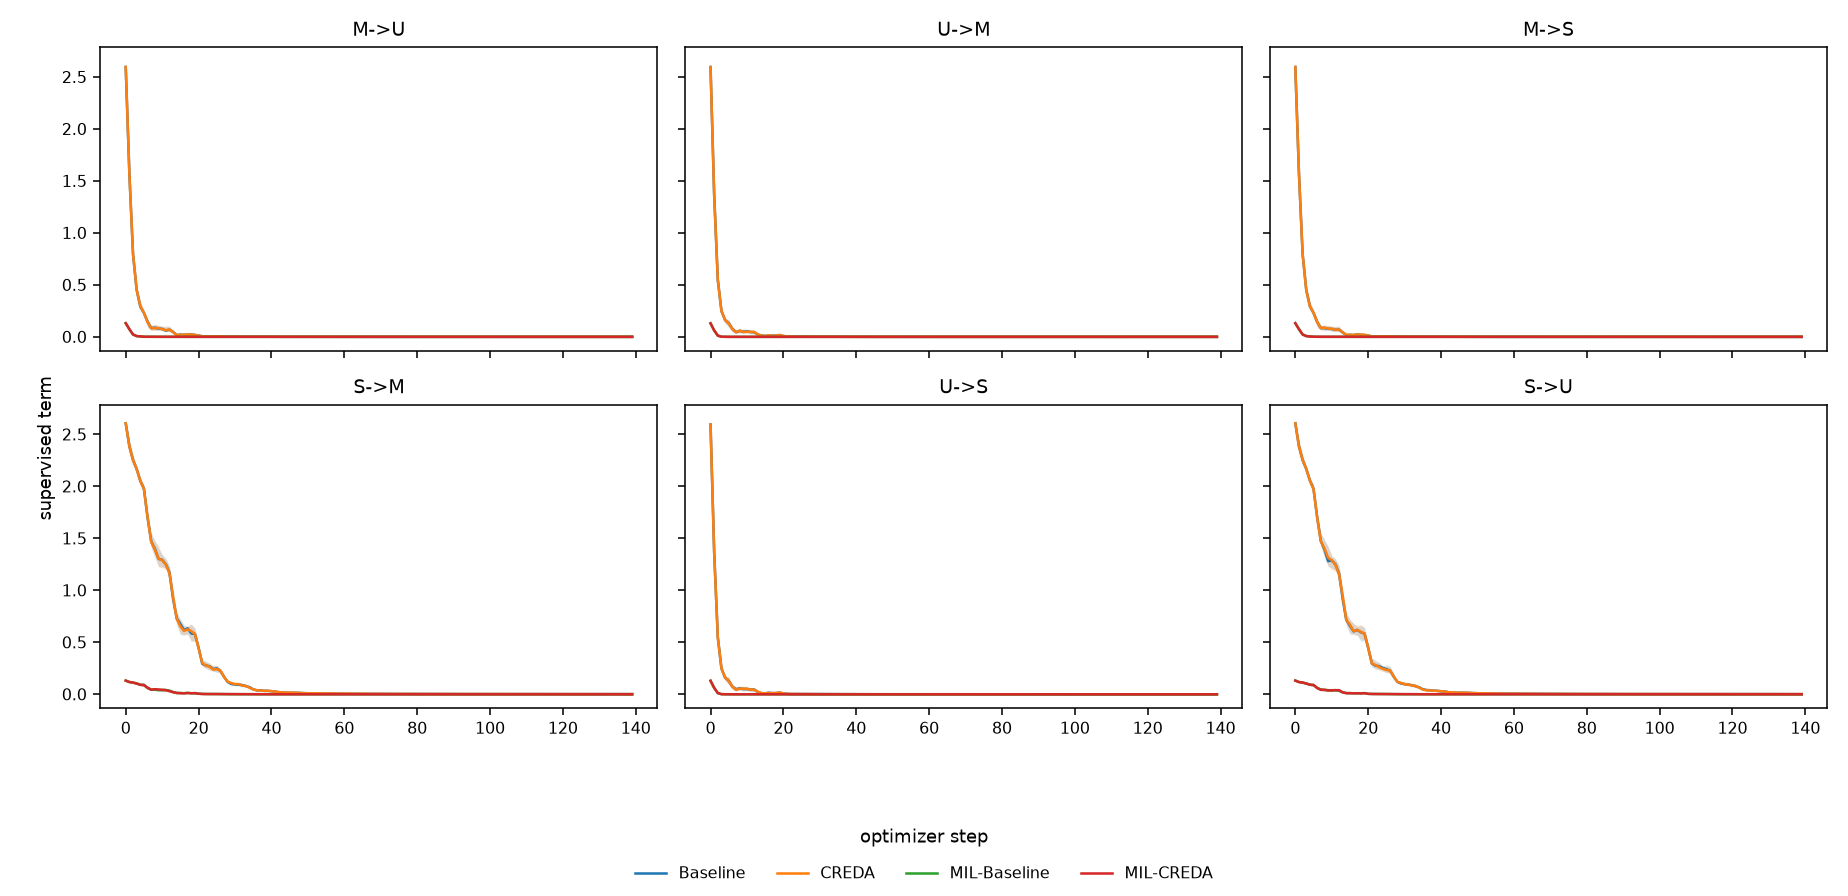

In [31]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.supervised_curves(RESULTS / "curves" / "supervised.pdf")))

## 5 · Las curvas del término de adaptación

Cuánto vale cada término de adaptación a lo largo del entrenamiento. La banda
sombreada es [0, 1]: la §5 normaliza los términos de MIL-CREDA exactamente sobre
ese intervalo y la puntuación del trabajo previo no tiene esa cota, así que si una
curva se queda adentro de la banda —y si ocupa la misma parte de ella de una
transferencia a otra— es la afirmación misma y no una ilustración de ella.
Buscamos curvas dentro de la banda y estables entre pares de dominios.

In [32]:
show(tables.objective("adaptation"))

> **Buscamos que la curva viva dentro de [0, 1] y tienda a cero**, y que ocupe la misma parte del intervalo en las seis transferencias. Salirse de la banda o cambiar de escala entre pares de dominios es el hallazgo.

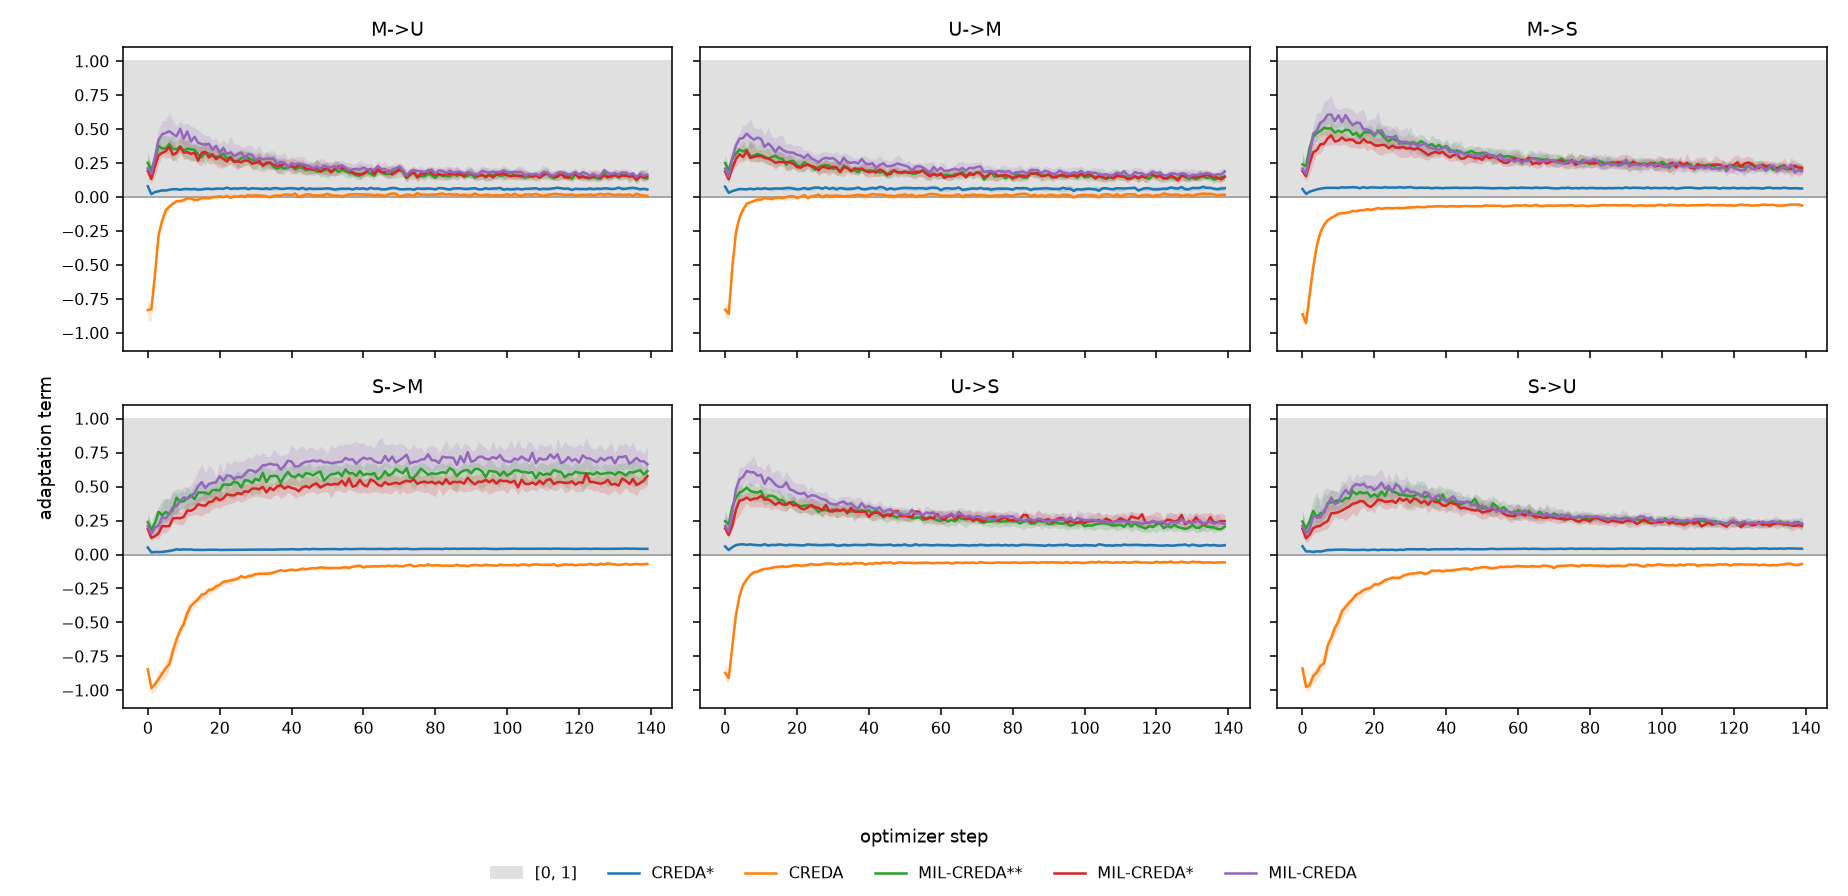

In [33]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.adaptation_curves(RESULTS / "curves" / "adaptation.pdf")))

## 6 · Cuánto del objetivo comanda cada término

Qué proporción del objetivo se lleva de verdad cada término declarado. Sin este
panel, «el término no tuvo efecto» y «el término no tuvo peso» son la misma
figura. El coeficiente está fijo en `RAMP_CEILING` para todos los métodos, y fijar
el coeficiente no fija la proporción: un término cuya magnitud difiere en un orden
entre métodos es una diferencia que nadie declaró, y un peldaño que la ignora le
acredita al mecanismo lo que hizo la escala. Buscamos proporciones comparables
entre métodos, porque es lo que hace legible al peldaño.

In [34]:
show(tables.objective("contribution"))

> **Buscamos que ningún método quede en cero y que los valores sean comparables entre sí.** En cero, «el término no hizo nada» y «el término no pesó nada» son la misma figura; con órdenes distintos entre métodos, el peldaño le acredita al mecanismo lo que hizo la escala.

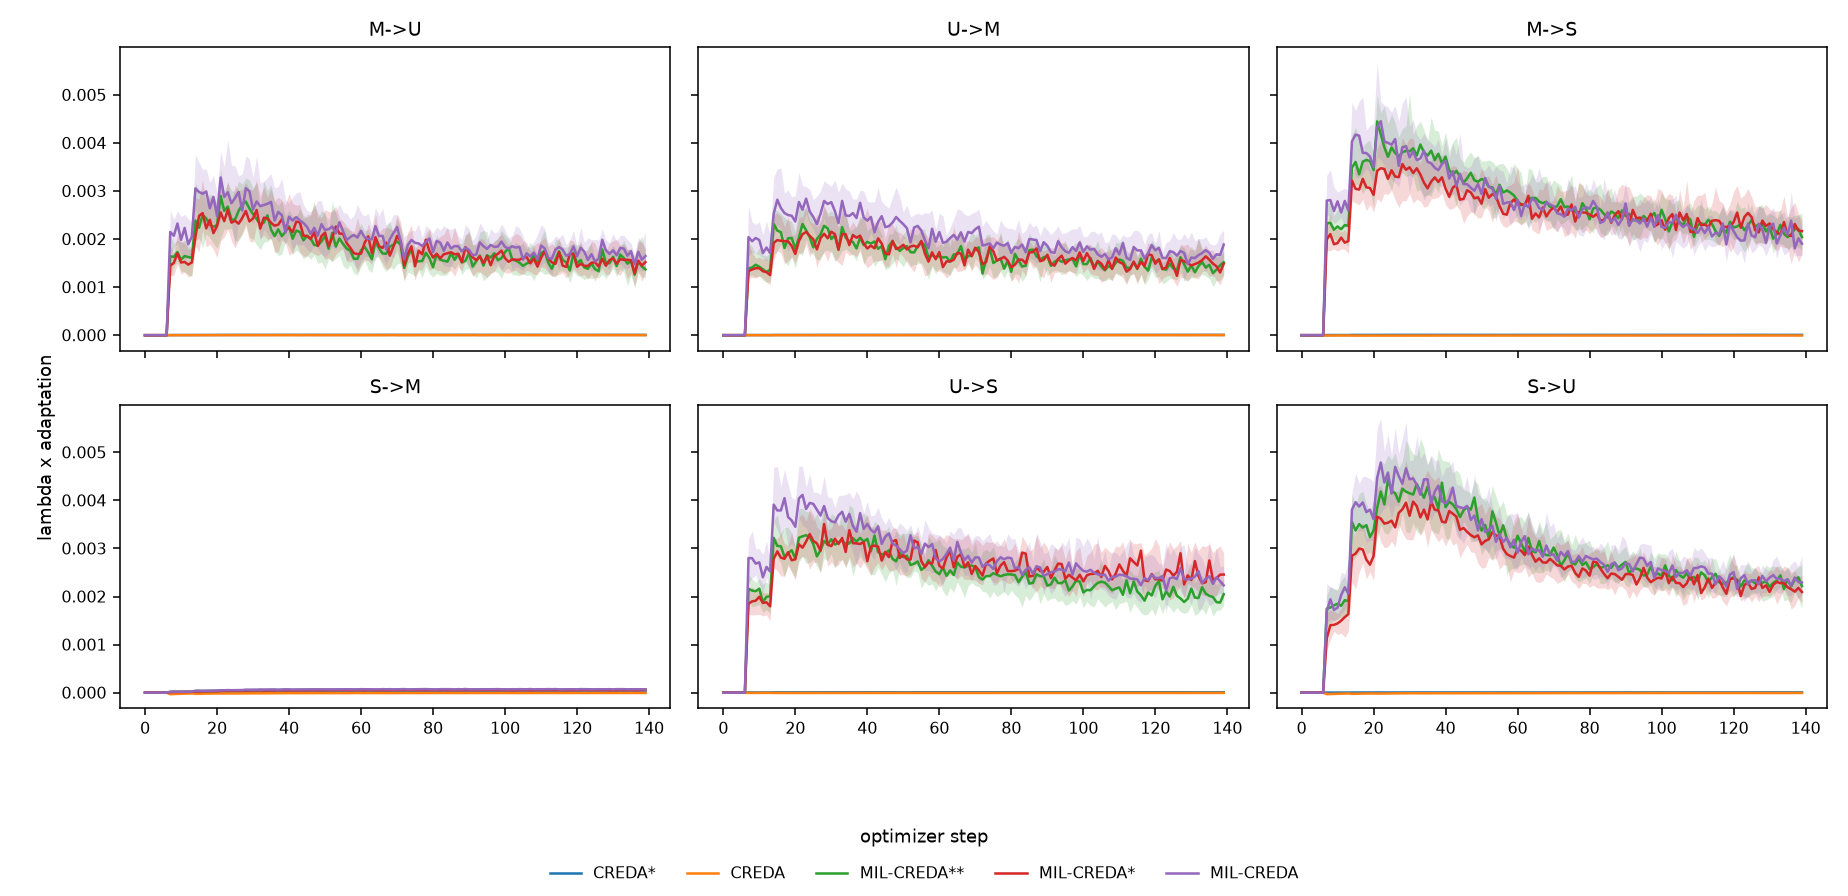

In [35]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.contribution_curves(RESULTS / "curves" / "contribution.pdf")))

## 7 · El registro

Escribe las mismas tablas y conclusiones de arriba en `report.txt` y `report.md`, y
al lado `runs.jsonl` y `summary.json`, que son lo que lee `Benchmark_Latent_v1`. Una sesión
posterior tiene que poder saber que esta corrida ocurrió, bajo qué reducción y contra
qué revisión, y nada de eso vive fuera del repositorio. Se genera junto con los
resultados y nunca se escribe a mano: un resumen escrito a mano es una segunda fuente
de verdad, se desactualiza en silencio y se le cree igual.

In [36]:
# Same fallback as cells 10-11 above: `gridPerRun` only exists on a
# distributed campaign's summary, so a single-machine run keeps writing the
# pooled `seconds` block exactly as before.
seconds_plain = (tables.render_per_run(summary["gridPerRun"], "seconds")
                  if summary.get("gridPerRun")
                  else tables.render(runs, "seconds", summary["reduction"]))
seconds_md = (tables.render_per_run(summary["gridPerRun"], "seconds", markdown=True)
              if summary.get("gridPerRun")
              else tables.render(runs, "seconds", summary["reduction"], markdown=True))
seconds_conclusion = (tables.conclusion_per_run("seconds")
                       if summary.get("gridPerRun")
                       else tables.conclusion(runs, "seconds", summary["reduction"]))

bloques = [
    harness.header(reduction),
    tables.stamp(summary["reduction"]),
    tables.render_ceilings(registro_busqueda),
    tables.conclusion_ceilings(registro_busqueda),
    tables.render_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS),
    tables.conclusion_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS),
    seconds_plain,
    seconds_conclusion,
    tables.render(runs, "sourceAccuracy", summary["reduction"]),
    tables.conclusion(runs, "sourceAccuracy", summary["reduction"]),
    tables.render_rungs(summary, "sourceAccuracy"),
    tables.conclusion_rungs(summary, "sourceAccuracy"),
    tables.render(runs, "targetAccuracy", summary["reduction"]),
    tables.conclusion(runs, "targetAccuracy", summary["reduction"]),
    tables.render_rungs(summary, "targetAccuracy"),
    tables.conclusion_rungs(summary, "targetAccuracy"),
]
(RESULTS / "report.txt").write_text("\n\n".join(bloques), encoding="utf-8")

(RESULTS / "report.md").write_text("\n\n".join([
    f"# Informe de campaña (v1) — {config.REVISION}",
    tables.stamp(summary["reduction"], markdown=True),
    "## 0 · El techo de cada familia",
    tables.render_ceilings(registro_busqueda, markdown=True),
    tables.conclusion_ceilings(registro_busqueda),
    "### 0b · Qué techo rige en cada transferencia",
    tables.render_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS, markdown=True),
    tables.conclusion_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS),
    "## 1 · Tiempo de entrenamiento (más bajo es mejor)",
    seconds_md,
    seconds_conclusion,
    "## 2 · Exactitud en fuente (más alto es mejor)",
    tables.render(runs, "sourceAccuracy", summary["reduction"], markdown=True),
    tables.conclusion(runs, "sourceAccuracy", summary["reduction"]),
    "### 2b · Peldaños en fuente",
    tables.render_rungs(summary, "sourceAccuracy", markdown=True),
    tables.conclusion_rungs(summary, "sourceAccuracy"),
    "## 3 · Exactitud en destino (más alto es mejor)",
    tables.render(runs, "targetAccuracy", summary["reduction"], markdown=True),
    tables.conclusion(runs, "targetAccuracy", summary["reduction"]),
    "### 3b · Peldaños en destino",
    tables.render_rungs(summary, "targetAccuracy", markdown=True),
    tables.conclusion_rungs(summary, "targetAccuracy"),
]), encoding="utf-8")

print("escritos:")
for path in sorted(RESULTS.iterdir()):
    print(" ", path.relative_to(config.REPOSITORY))

escritos:
  MIL-CREDA/Results/Benchmark/PROVENANCE.txt
  MIL-CREDA/Results/Benchmark/ceilings.json
  MIL-CREDA/Results/Benchmark/ceilings.pilot.json
  MIL-CREDA/Results/Benchmark/curves
  MIL-CREDA/Results/Benchmark/latent
  MIL-CREDA/Results/Benchmark/latent.json
  MIL-CREDA/Results/Benchmark/latent.md
  MIL-CREDA/Results/Benchmark/report.md
  MIL-CREDA/Results/Benchmark/report.txt
  MIL-CREDA/Results/Benchmark/runs.jsonl
  MIL-CREDA/Results/Benchmark/shards
  MIL-CREDA/Results/Benchmark/summary.json


In [37]:
# El sello: contra qué código corrió este informe. Sin él, un informe viejo y uno
# recién generado se ven idénticos y el viejo se sigue creyendo.
from MIL_CREDA_Benchmark import report_digest

print(report_digest.stamp())

SOURCES-SHA256 b0c68d3313572f7bf6d42febe23292778f582f6dfc614bfdecaa0bc9ccd21e86
